Model-based Collaborative Filtering Deep Learning

In [3]:
import os
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Шлях до файлів
data_path = os.path.join('..', 'data')
model_path = os.path.join(data_path, 'anime_model_v1.keras')
test_path = os.path.join(data_path, 'processed', 'test_final_encoded.parquet')


# Завантаження моделі
print("Завантаження моделі...")
model = tf.keras.models.load_model(model_path)

# Завантаження тестових даних
print("Завантаження тестових даних...")
test = pd.read_parquet(test_path)

Завантаження моделі...
Завантаження тестових даних...


In [4]:
print("\n--- ОЦІНКА НА ТЕСТОВИХ ДАНИХ ---")
results = model.evaluate(
    x=[test['user_encoded'], test['anime_encoded']], 
    y=test['target'], 
    batch_size=10000,
    verbose=1
)

loss, mse, mae = results
print(f"\nLoss (Binary Crossentropy): {loss:.4f}")
print(f"Mean Squared Error (MSE):  {mse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")

# Порівняння з автором (MSE ~0.07, MAE ~0.19)
print(f"\nРізниця MSE з референсом: {abs(mse - 0.07):.4f}")


--- ОЦІНКА НА ТЕСТОВИХ ДАНИХ ---
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.5309 - mae: 0.0989 - mse: 0.0175

Loss (Binary Crossentropy): 0.5309
Mean Squared Error (MSE):  0.0175
Mean Absolute Error (MAE): 0.0989

Різниця MSE з референсом: 0.0525


274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


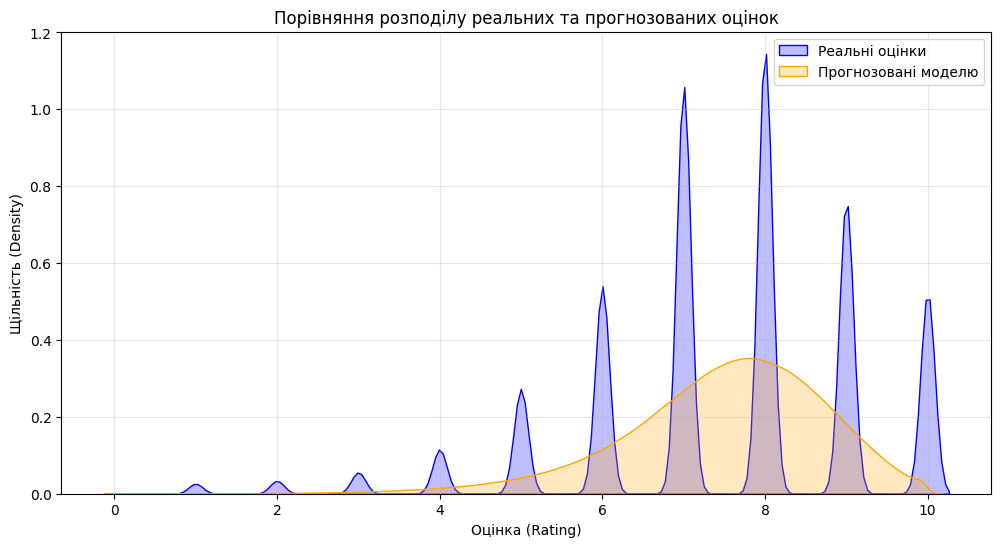

In [5]:
# Отримання прогнозів
predictions = model.predict([test['user_encoded'], test['anime_encoded']], batch_size=10000)

# Повертаємо до шкали 1-10
actual_ratings = test['target'] * 10.0
predicted_ratings = predictions.flatten() * 10.0

# Візуалізація
plt.figure(figsize=(12, 6))

# Гістограма реальних vs прогнозованих оцінок
sns.kdeplot(actual_ratings, label='Реальні оцінки', fill=True, color="blue")
sns.kdeplot(predicted_ratings, label='Прогнозовані моделю', fill=True, color="orange")

plt.title('Порівняння розподілу реальних та прогнозованих оцінок')
plt.xlabel('Оцінка (Rating)')
plt.ylabel('Щільність (Density)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

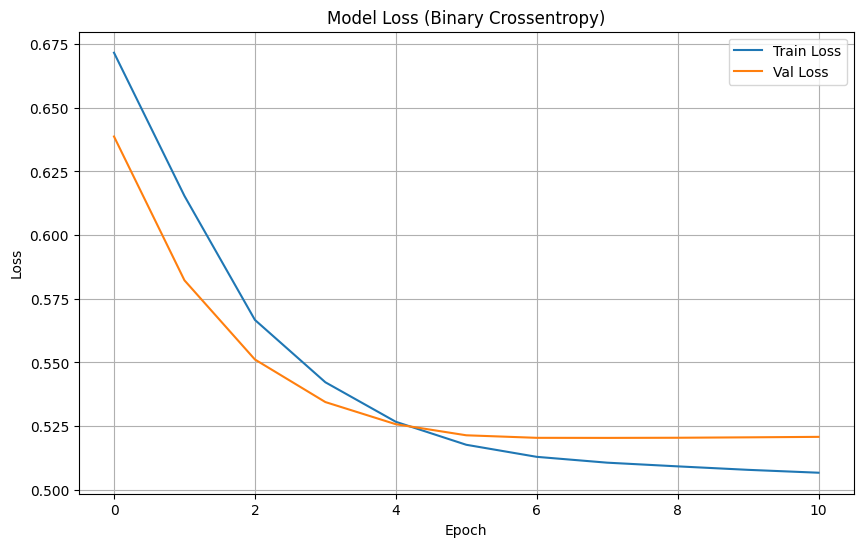

In [6]:
history_path = os.path.join(data_path, 'history.csv')
history_df = pd.read_csv(history_path)

plt.figure(figsize=(10, 6))
plt.plot(history_df['loss'], label='Train Loss')
plt.plot(history_df['val_loss'], label='Val Loss')
plt.title('Model Loss (Binary Crossentropy)')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

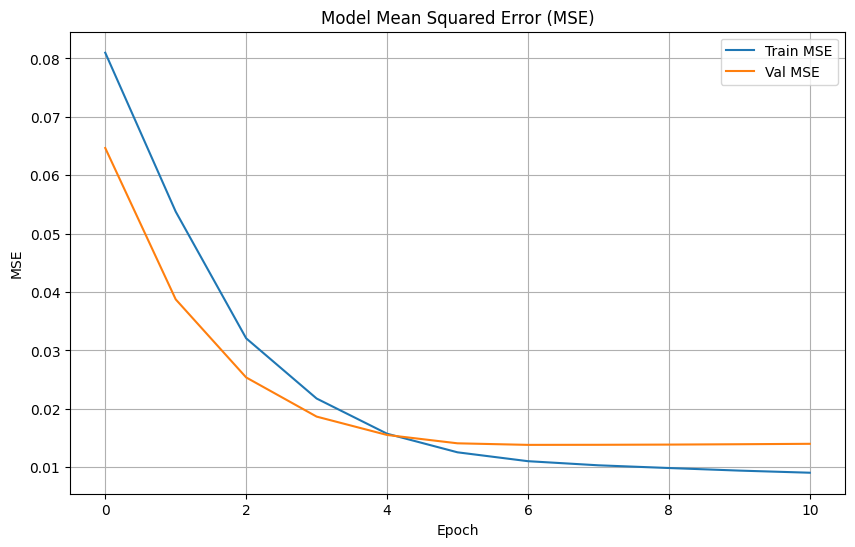

In [7]:
# Аналогічно можна побудувати графіки для MSE або MAE
plt.figure(figsize=(10, 6))
plt.plot(history_df['mse'], label='Train MSE')
plt.plot(history_df['val_mse'], label='Val MSE')
plt.title('Model Mean Squared Error (MSE)')
plt.ylabel('MSE')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

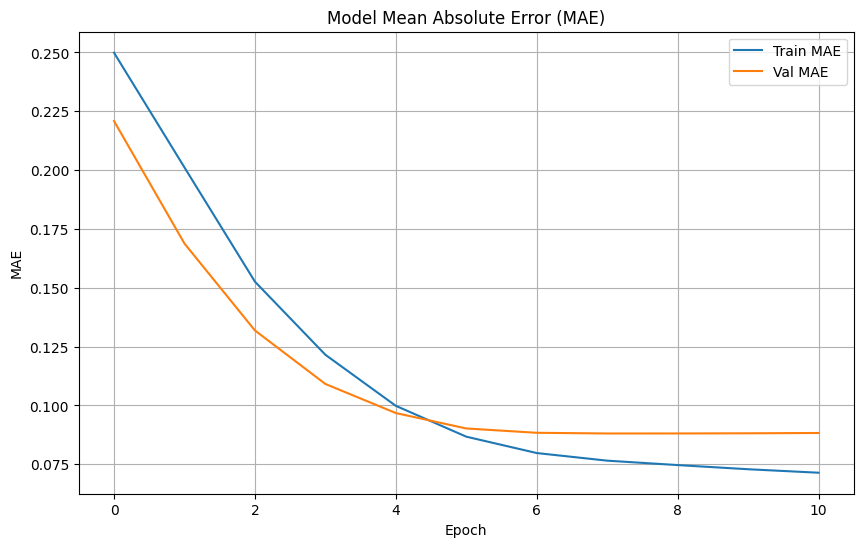

In [8]:
# Аналогічно можна побудувати графіки для MSE або MAE
plt.figure(figsize=(10, 6))
plt.plot(history_df['mae'], label='Train MAE')
plt.plot(history_df['val_mae'], label='Val MAE')
plt.title('Model Mean Absolute Error (MAE)')
plt.ylabel('MAE')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

In [9]:
# Повертаємо до шкали 1-10 та додаємо в датафрейм
test['predicted_rating'] = predicted_ratings
test['actual_rating'] = actual_ratings

# Розраховуємо абсолютну помилку (MAE) та квадрат помилки (MSE) для кожного запису
test['abs_error'] = abs(test['actual_rating'] - test['predicted_rating'])
test['sq_error'] = (test['actual_rating'] - test['predicted_rating'])**2

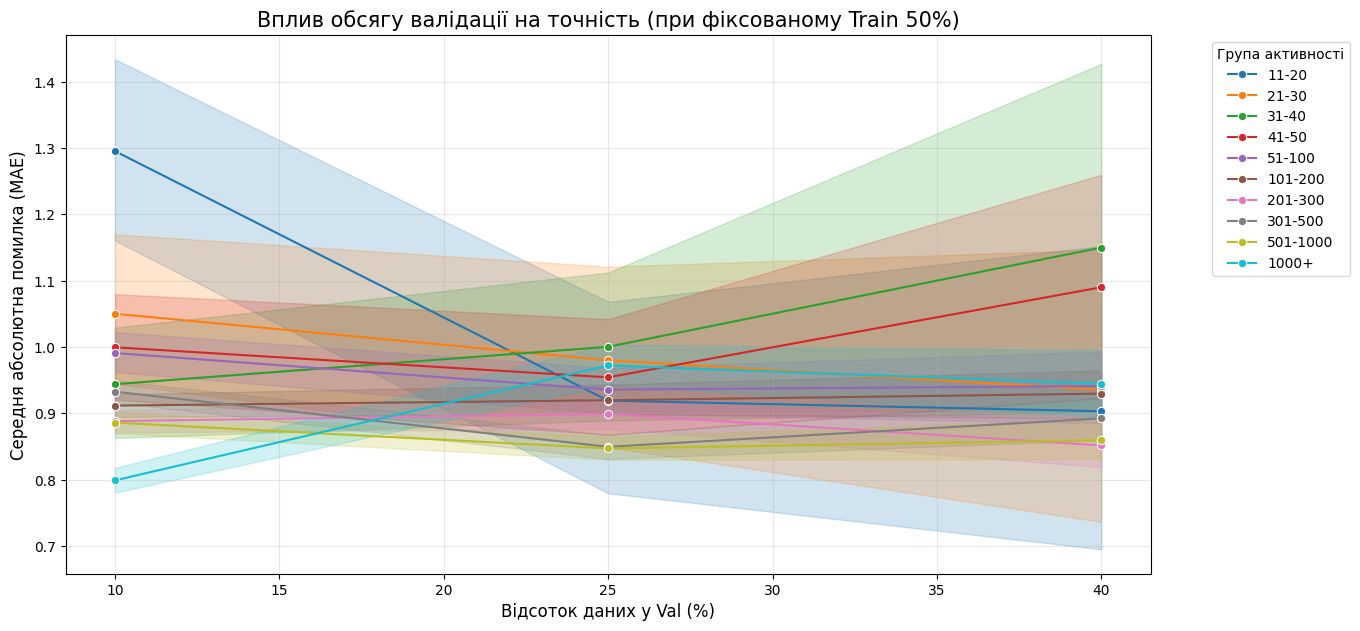

In [10]:
# Фільтруємо серію B (Fixed Train)
df_series_b = test[test['series_id'] == 'B_FixedTrain'].copy()

plt.figure(figsize=(14, 7))
sns.lineplot(
    data=df_series_b, 
    x='y_pct', # Відсоток валідації
    y='abs_error', 
    hue='activity_group', 
    marker='o'
)

plt.title('Вплив обсягу валідації на точність (при фіксованому Train 50%)', fontsize=15)
plt.xlabel('Відсоток даних у Val (%)', fontsize=12)
plt.ylabel('Середня абсолютна помилка (MAE)', fontsize=12)
plt.legend(title='Група активності', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

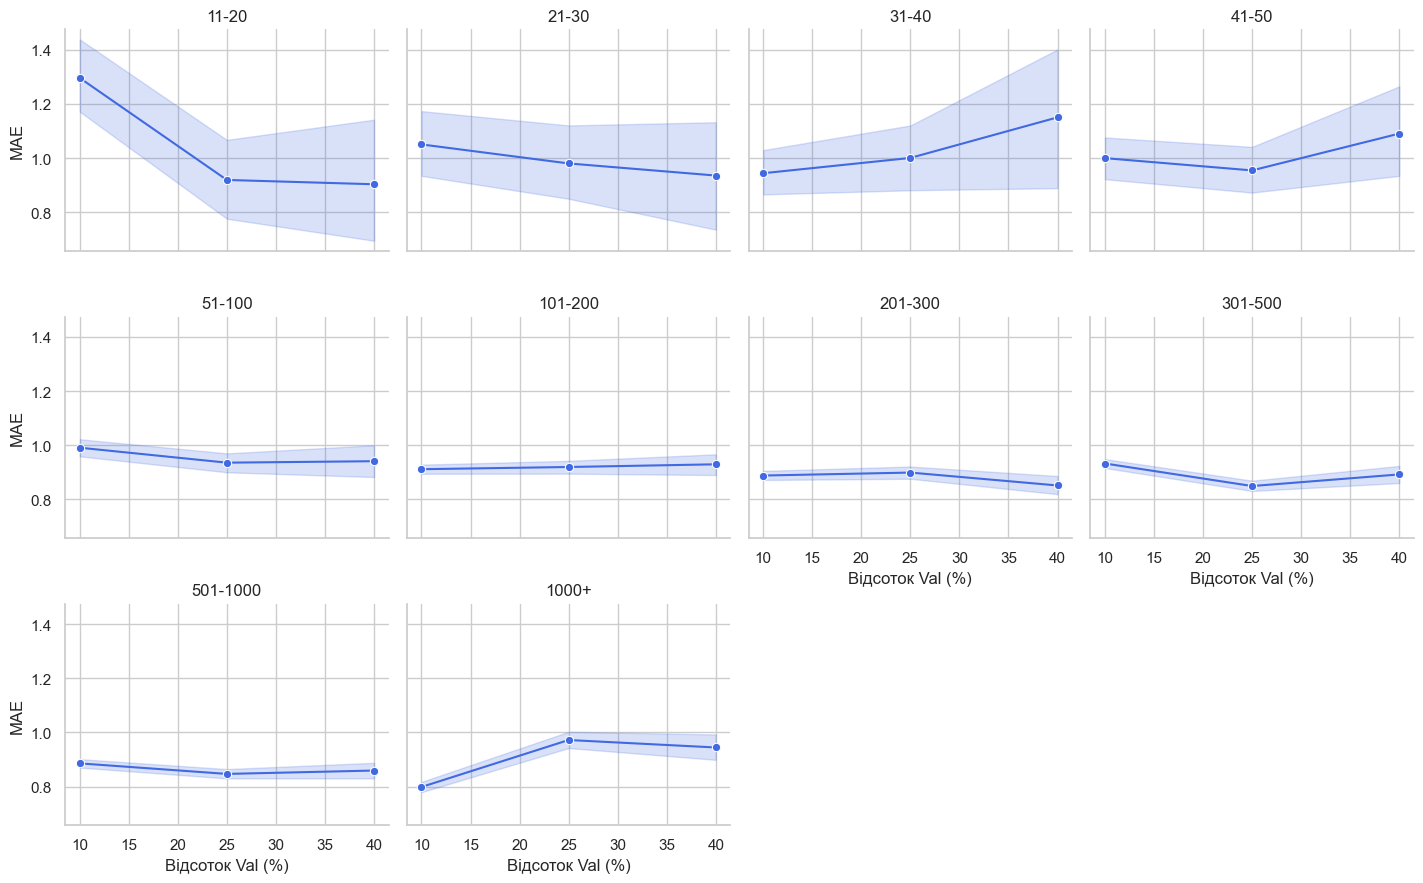

In [11]:
# Налаштування стилю
sns.set_theme(style="whitegrid")

# Створення фасетної сітки
g = sns.FacetGrid(
    df_series_b, 
    col="activity_group", 
    col_wrap=4,           # по 4 графіки в рядку
    height=3, 
    aspect=1.2,
    sharey=True           # спільна шкала Y для чесного порівняння
)

# Малюємо лінії на кожному підграфіку
g.map_dataframe(
    sns.lineplot, 
    x="y_pct", 
    y="abs_error", 
    marker="o", 
    color="royalblue"
    #errorbar=None         # прибираємо тіні для чіткості, або залиште, якщо їх мало
)

g.set_axis_labels("Відсоток Val (%)", "MAE")
g.set_titles(col_template="{col_name}")
g.tight_layout()

plt.show()

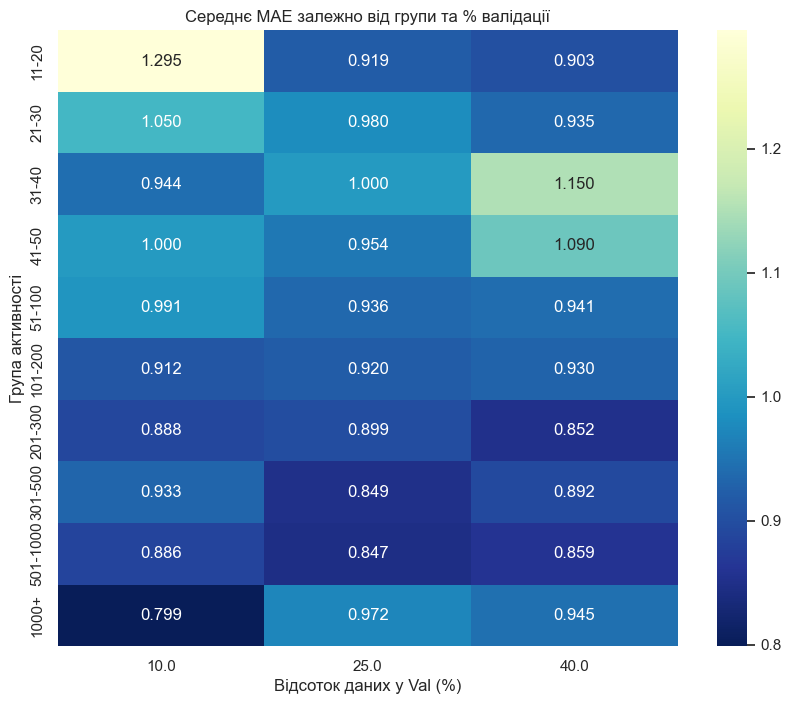

In [12]:
# Готуємо дані для теплової карти (середнє MAE)
heatmap_data = df_series_b.pivot_table(
    index='activity_group', 
    columns='y_pct', 
    values='abs_error', 
    aggfunc='mean'
)

plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, annot=True, fmt=".3f", cmap="YlGnBu_r")
plt.title("Середнє MAE залежно від групи та % валідації")
plt.ylabel("Група активності")
plt.xlabel("Відсоток даних у Val (%)")
plt.show()

C:\Users\Anton\AppData\Local\Temp\ipykernel_21508\625343176.py:10: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=df_series_b, x='y_pct', y='abs_error', hue='broad_group', marker='o', ci=None)


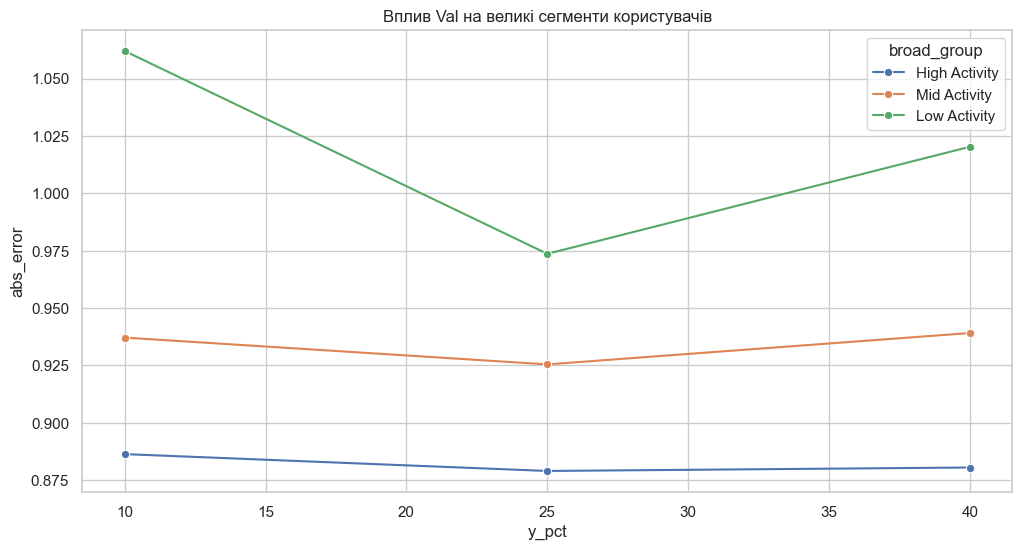

In [13]:
# Приклад агрегації (якщо ваші групи - це рядки)
def aggregate_groups(group):
    if group in ['11-20', '21-30', '31-40']: return 'Low Activity'
    if group in ['41-50', '51-100', '101-200']: return 'Mid Activity'
    return 'High Activity'

df_series_b['broad_group'] = df_series_b['activity_group'].apply(aggregate_groups)

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_series_b, x='y_pct', y='abs_error', hue='broad_group', marker='o', ci=None)
plt.title("Вплив Val на великі сегменти користувачів")
plt.show()

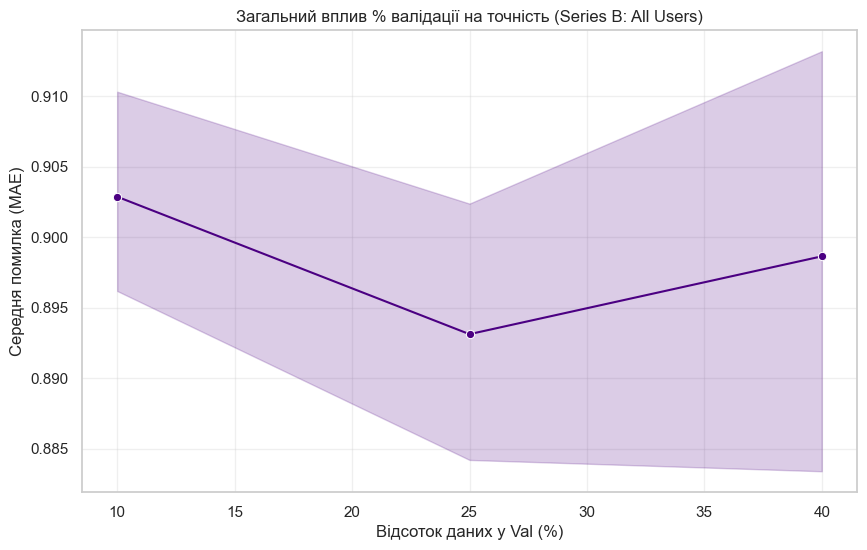

In [14]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_series_b, x='y_pct', y='abs_error', marker='o', color='indigo')
plt.title('Загальний вплив % валідації на точність (Series B: All Users)')
plt.xlabel('Відсоток даних у Val (%)')
plt.ylabel('Середня помилка (MAE)')
plt.grid(True, alpha=0.3)
plt.show()

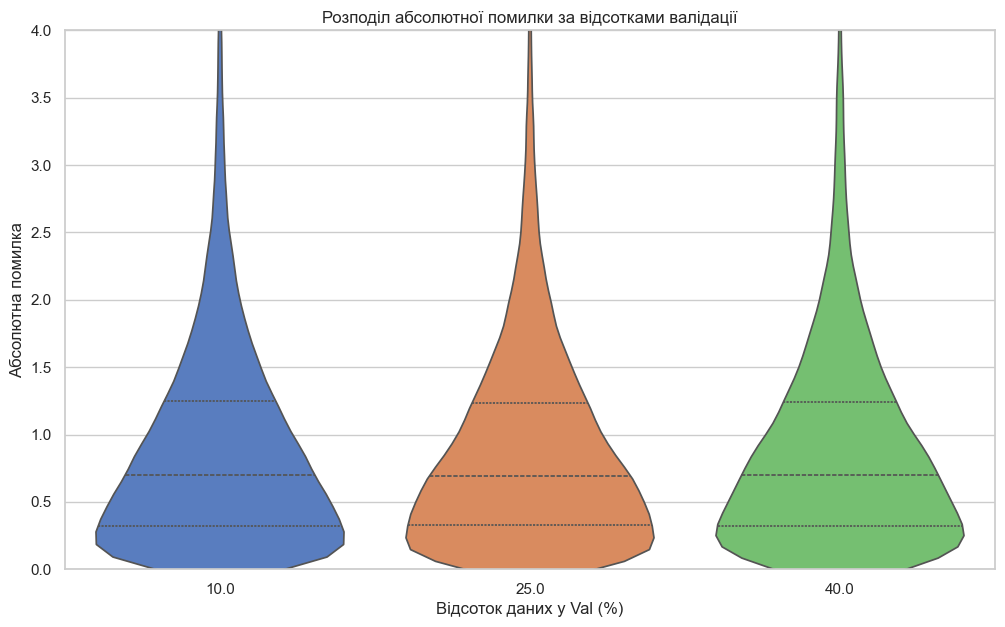

In [15]:
plt.figure(figsize=(12, 7))
sns.violinplot(
    data=df_series_b, 
    x='y_pct', 
    y='abs_error', 
    hue='y_pct', # додаємо для кольору
    inner="quartile", # покаже медіану та квартилі
    palette="muted",
    legend=False
)
plt.title('Розподіл абсолютної помилки за відсотками валідації')
plt.xlabel('Відсоток даних у Val (%)')
plt.ylabel('Абсолютна помилка')
plt.ylim(0, 4) # фокусуємося на основній масі помилок
plt.show()

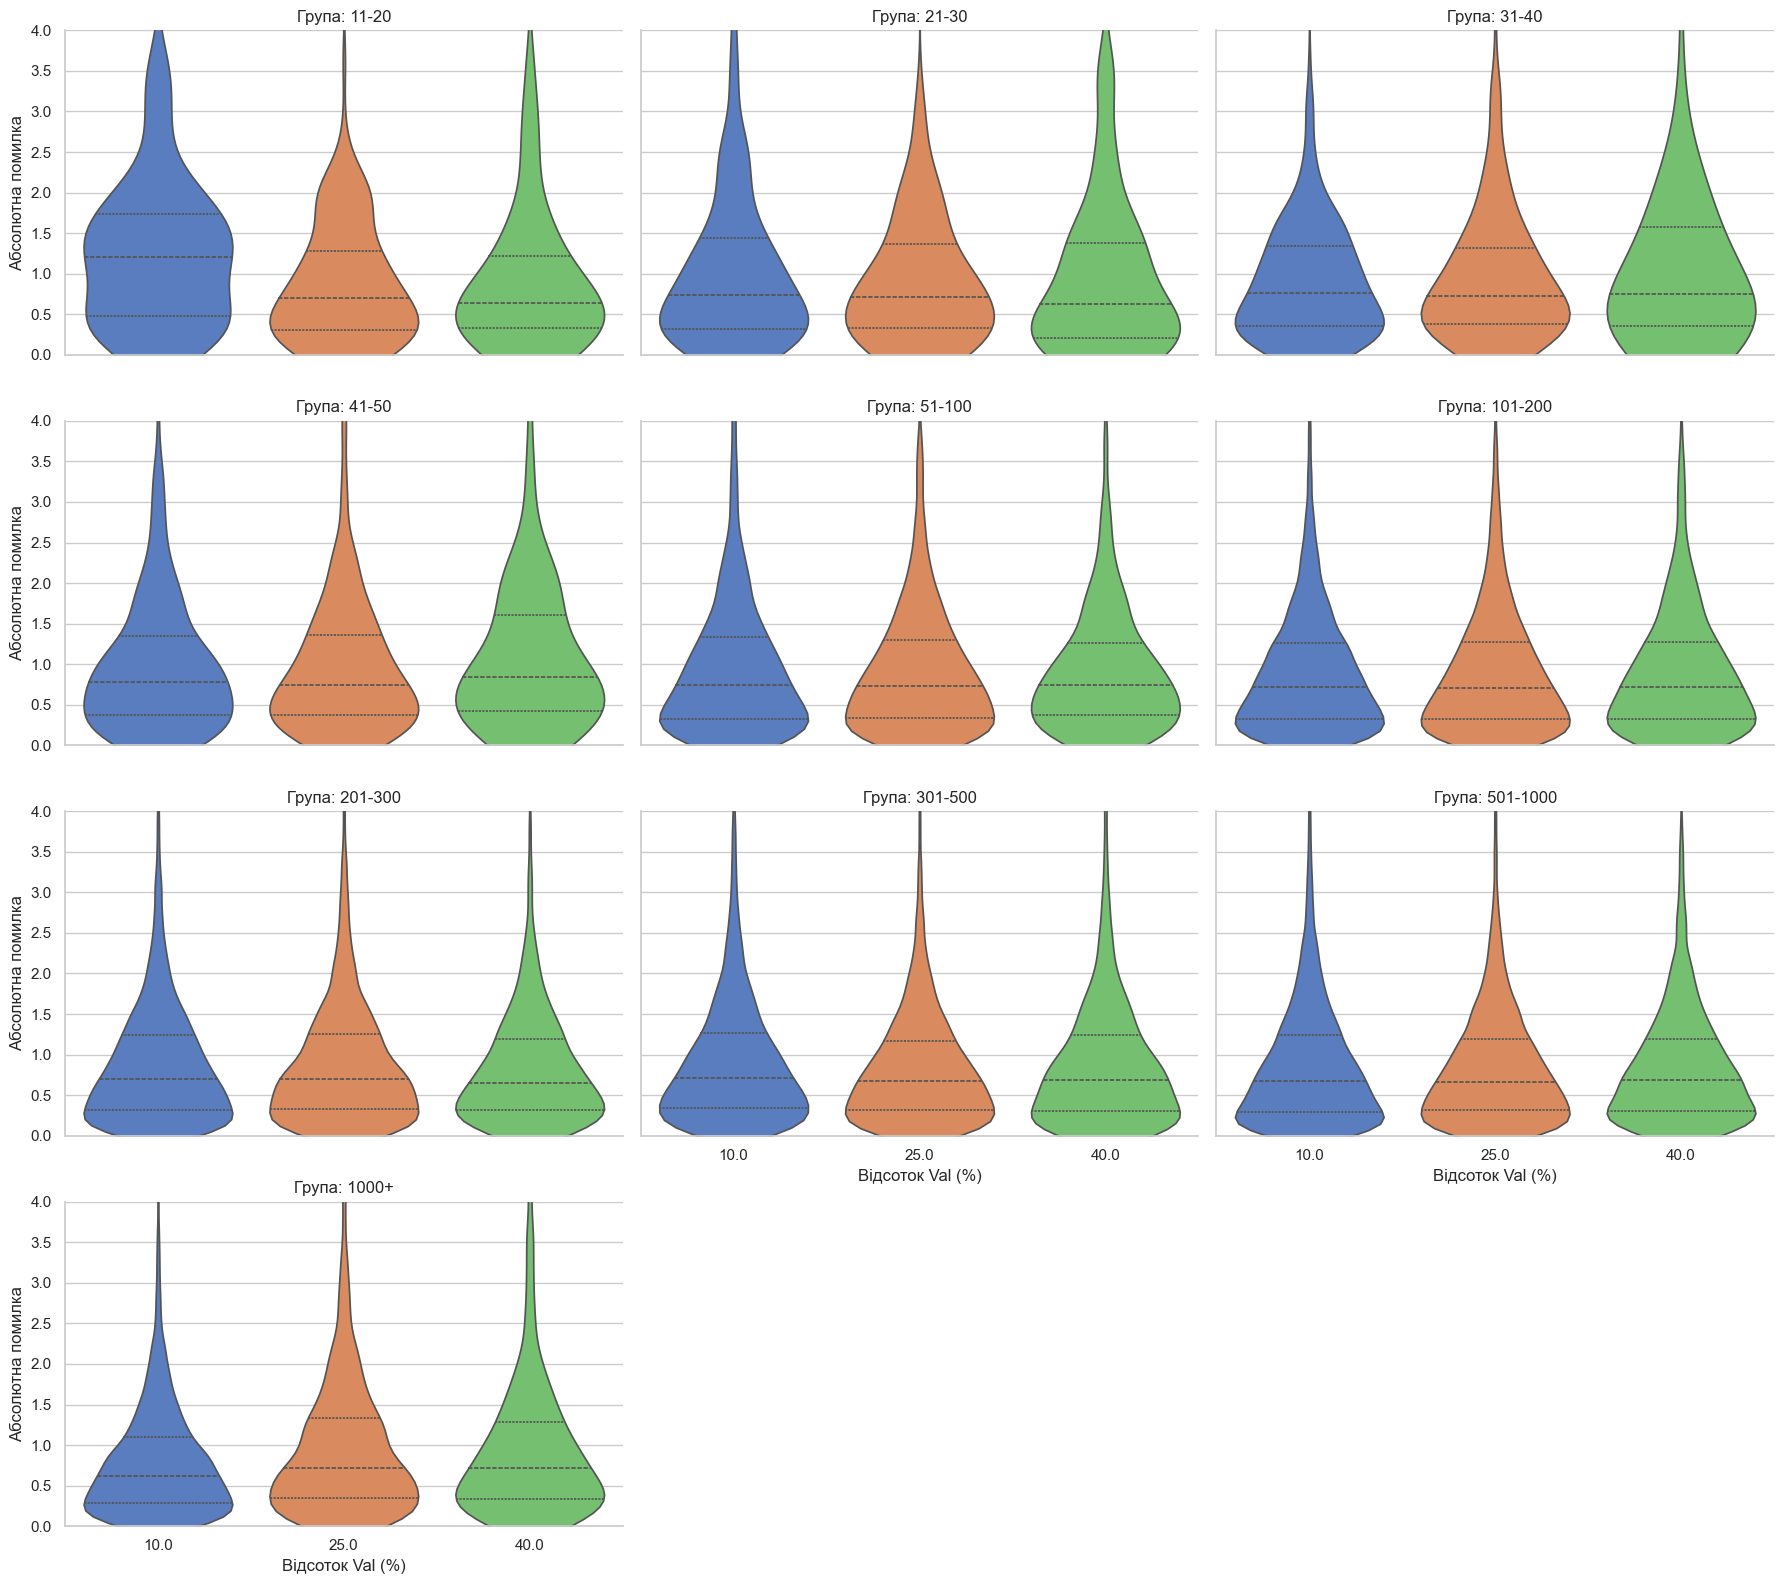

In [16]:
# Налаштовуємо стиль
sns.set_theme(style="whitegrid")

# Створюємо сітку: по 3-4 групи в рядку
g = sns.FacetGrid(
    df_series_b, 
    col="activity_group", 
    col_wrap=3, 
    height=4, 
    aspect=1.5,
    sharey=True # Залишаємо спільну шкалу для порівняння груп між собою
)

# Малюємо скрипки
g.map_dataframe(
    sns.violinplot, 
    x="y_pct", 
    y="abs_error", 
    hue="y_pct",
    inner="quartile",
    palette="muted",
    legend=False
)

# Налаштування осей та заголовків
g.set_axis_labels("Відсоток Val (%)", "Абсолютна помилка")
g.set_titles(col_template="Група: {col_name}")

# Обмежуємо Y до 4.0, щоб бачити деталі (більшість помилок там)
plt.ylim(0, 4)
plt.tight_layout()
plt.show()

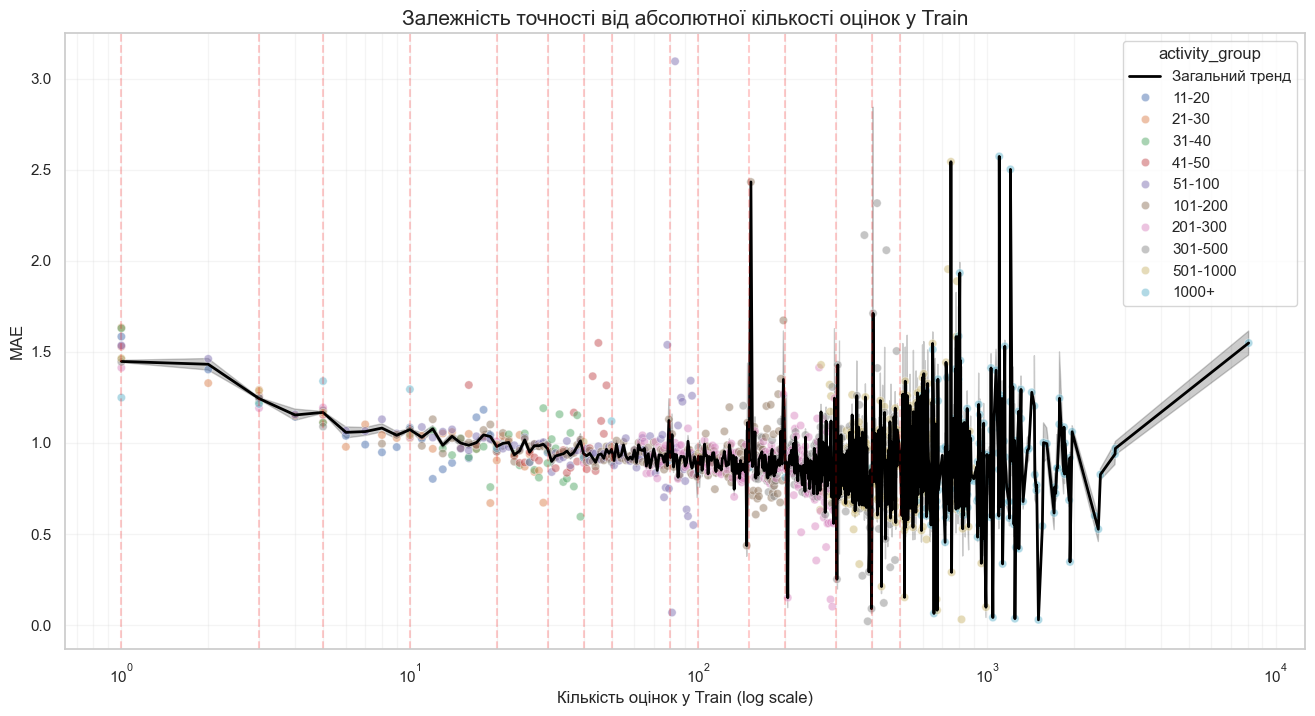

In [17]:
# Фільтруємо основний тест (без експериментальних серій)
df_main_test = test[test['series_id'].isna()].copy()

# Список ваших референтних значень для виділення на графіку
ref_counts = [1, 3, 5, 10, 20, 30, 40, 50, 80, 100, 150, 200, 300, 400, 500]

plt.figure(figsize=(16, 8))

# Будуємо загальну лінію тренду
sns.lineplot(data=df_main_test, x='train_count', y='abs_error', color='black', linewidth=2, label='Загальний тренд')

# Додаємо точки для кожної групи активності
sns.scatterplot(
    data=df_main_test.groupby(['train_count', 'activity_group'])['abs_error'].mean().reset_index(),
    x='train_count', y='abs_error', hue='activity_group', alpha=0.5
)

# Виділяємо референтні кількості вертикальними лініями
for ref in ref_counts:
    if ref <= df_main_test['train_count'].max():
        plt.axvline(x=ref, color='red', linestyle='--', alpha=0.2)

plt.xscale('log') # Логарифмічна шкала краще показує різницю між 1 та 10 оцінками
plt.title('Залежність точності від абсолютної кількості оцінок у Train', fontsize=15)
plt.xlabel('Кількість оцінок у Train (log scale)', fontsize=12)
plt.ylabel('MAE', fontsize=12)
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

C:\Users\Anton\AppData\Local\Temp\ipykernel_21508\3064900806.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_main_test, x='train_bin', y='abs_error', showfliers=False, palette='coolwarm')


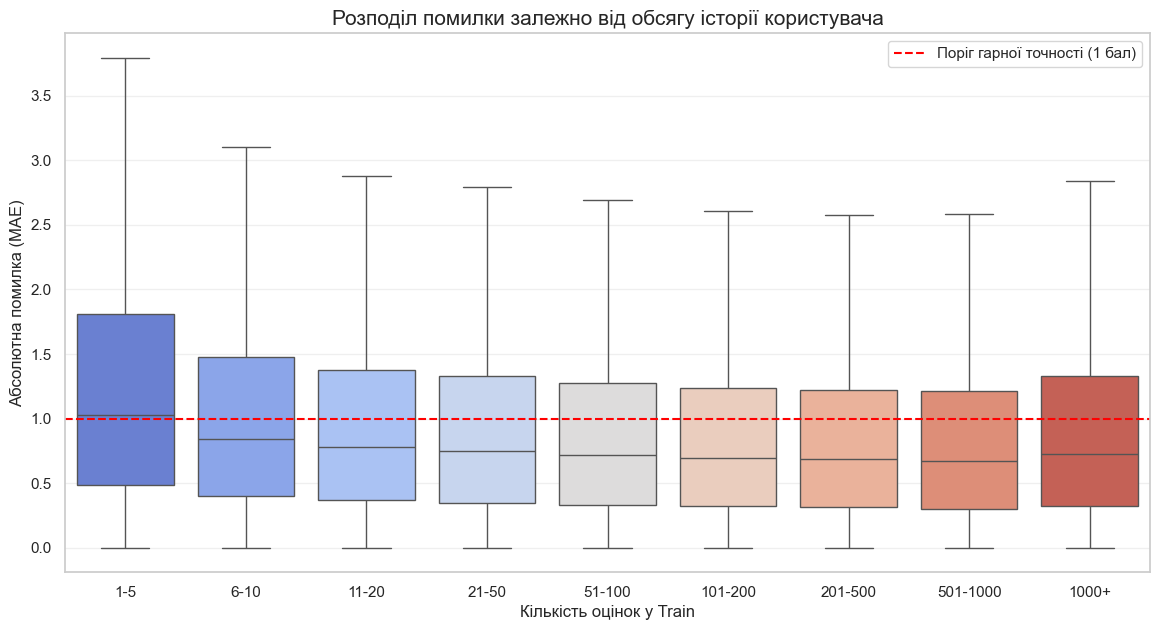

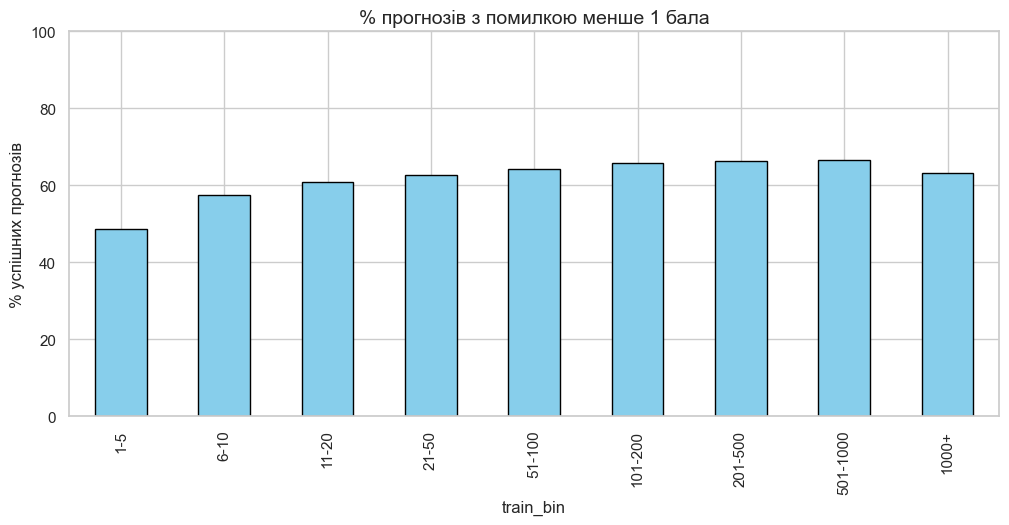

In [19]:
# 1. Створюємо логічні кошики (біни) для кількості оцінок
bins = [0, 5, 10, 20, 50, 100, 200, 500, 1000, 10000]
labels = ['1-5', '6-10', '11-20', '21-50', '51-100', '101-200', '201-500', '501-1000', '1000+']
df_main_test['train_bin'] = pd.cut(df_main_test['train_count'], bins=bins, labels=labels)

# 2. Візуалізація: Якість прогнозів по бінах
plt.figure(figsize=(14, 7))
sns.boxplot(data=df_main_test, x='train_bin', y='abs_error', showfliers=False, palette='coolwarm')
plt.axhline(y=1.0, color='red', linestyle='--', label='Поріг гарної точності (1 бал)')

plt.title('Розподіл помилки залежно від обсягу історії користувача', fontsize=15)
plt.xlabel('Кількість оцінок у Train', fontsize=12)
plt.ylabel('Абсолютна помилка (MAE)', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

# 3. Розрахунок "Ймовірності успіху"
success_rate = df_main_test.groupby('train_bin')['abs_error'].apply(lambda x: (x < 1.0).mean() * 100)

plt.figure(figsize=(12, 5))
success_rate.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('% прогнозів з помилкою менше 1 бала', fontsize=14)
plt.ylabel('% успішних прогнозів')
plt.ylim(0, 100)
plt.show()

In [25]:
df_main_test.groupby('train_bin')['abs_error'].mean()

train_bin
1-5         1.287644
6-10        1.071183
11-20       0.995708
21-50       0.957127
51-100      0.922007
101-200     0.889092
201-500     0.882935
501-1000    0.884152
1000+       0.957012
Name: abs_error, dtype: float64

C:\Users\Anton\AppData\Local\Temp\ipykernel_21508\4000309563.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(
C:\Users\Anton\AppData\Local\Temp\ipykernel_21508\4000309563.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
C:\Users\Anton\AppData\Local\Temp\ipykernel_21508\4000309563.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
C:\Users\Anton\AppData\Local\Temp\ipykernel_21508\4000309563.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xti

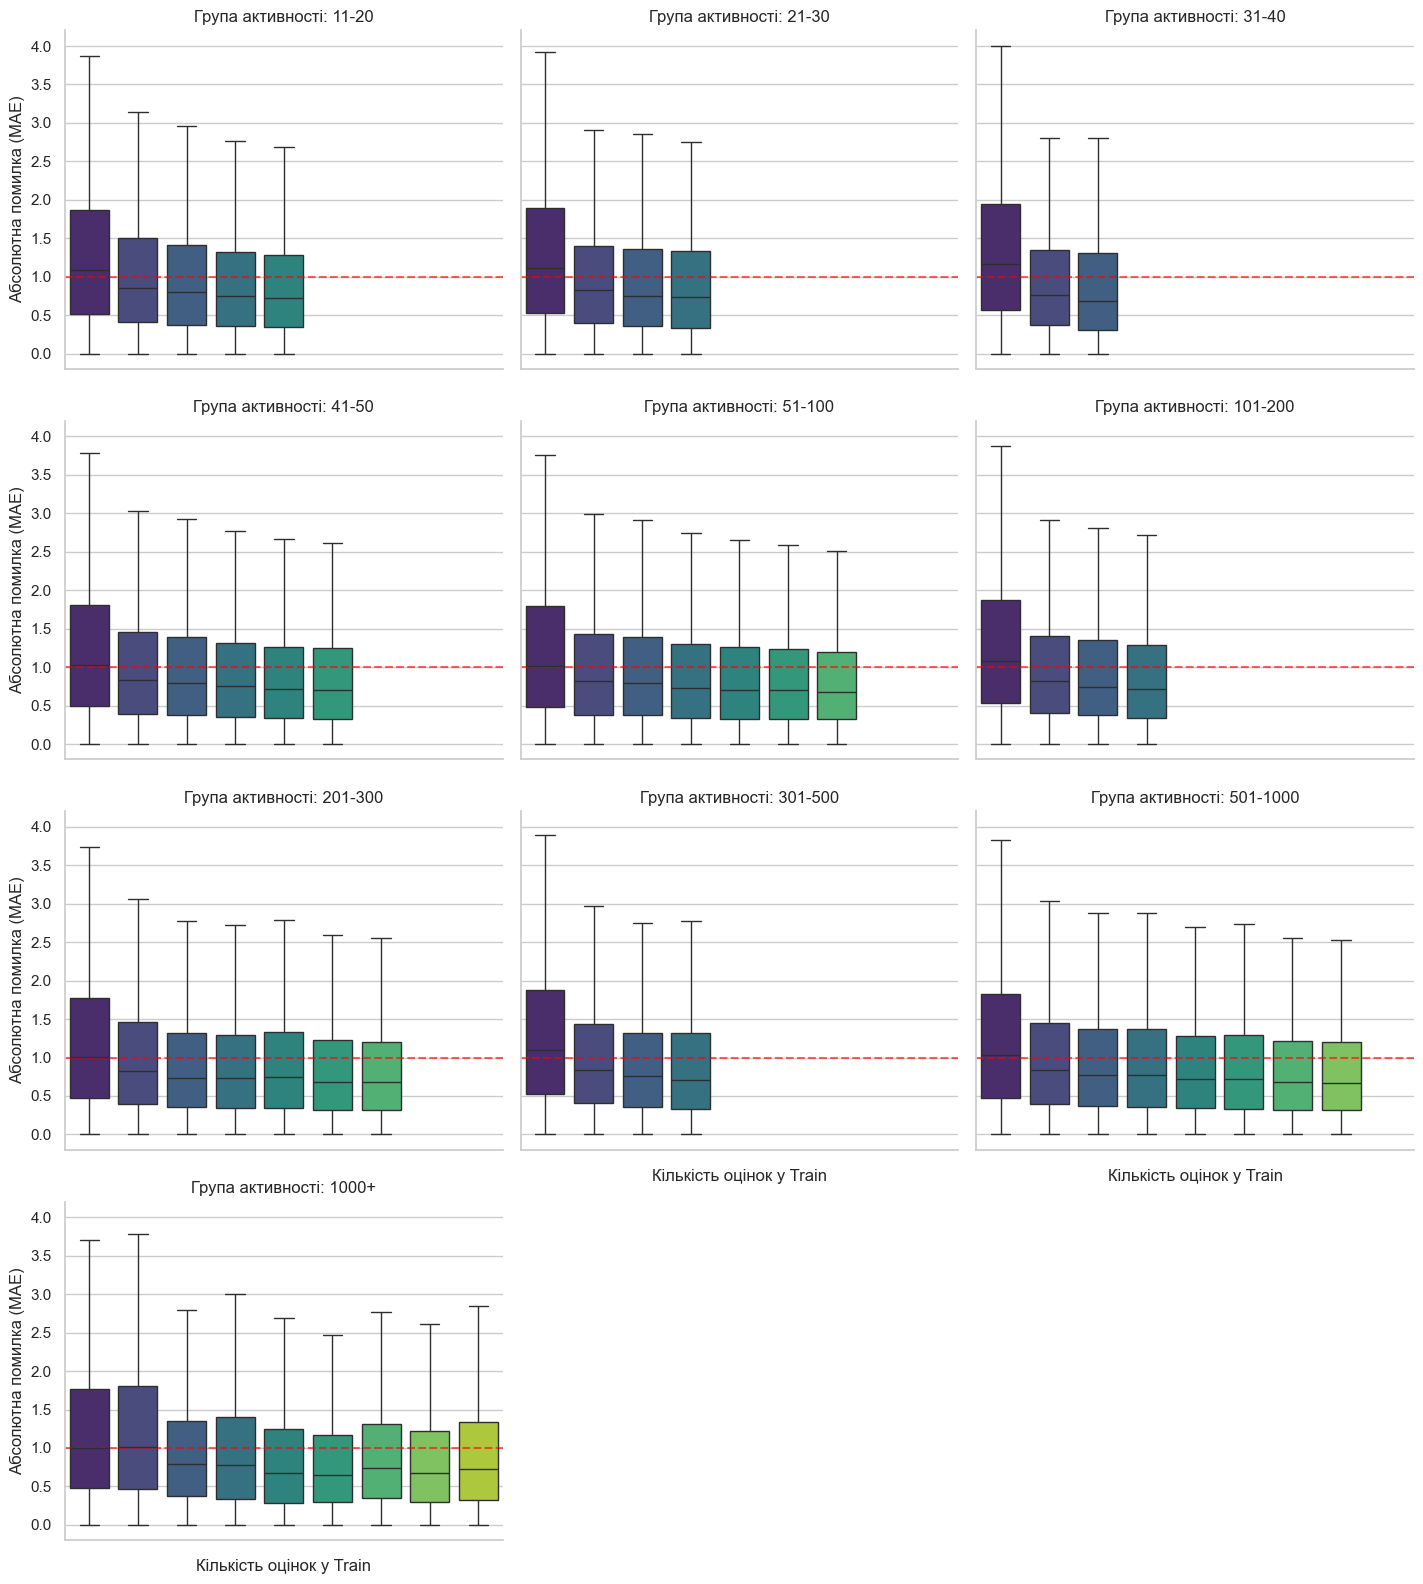

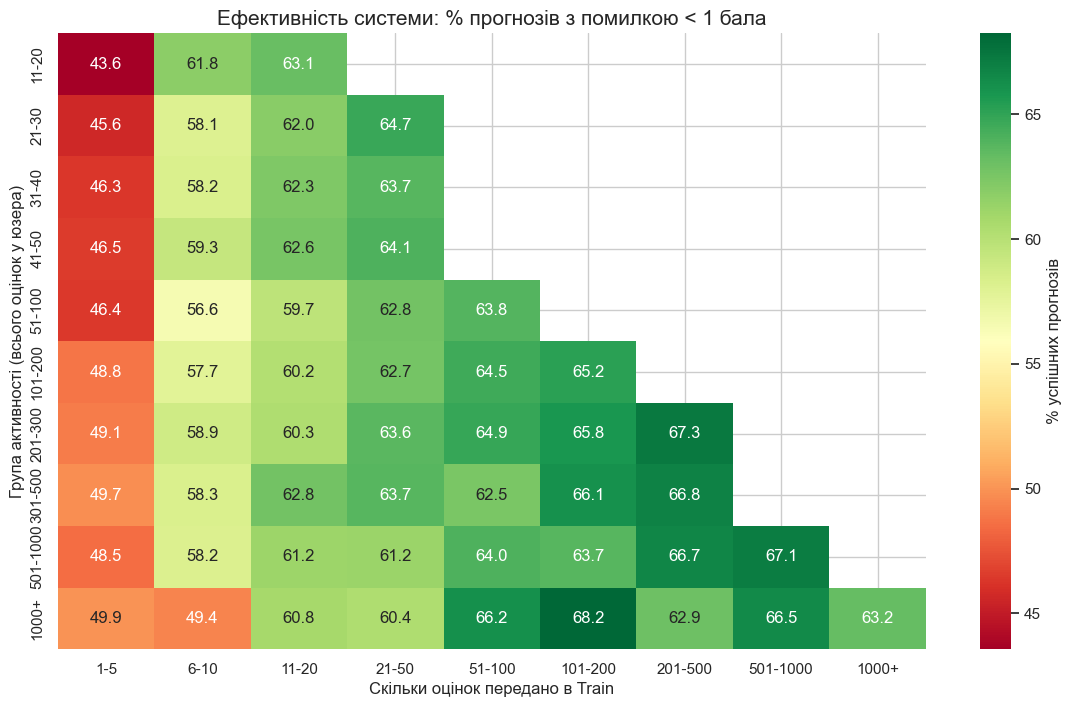

In [20]:
# --- 1. FacetGrid: Розподіл помилки для кожної групи окремо ---
g = sns.catplot(
    data=df_main_test,
    x='train_bin', 
    y='abs_error',
    col='activity_group', 
    col_wrap=3,           # по 3 графіки в рядку
    kind='box', 
    showfliers=False,     # прибираємо викиди для чистоти
    height=4, 
    aspect=1.2,
    palette='viridis'
)

# Додаємо референтну лінію 1.0 на кожен підграфік
for ax in g.axes.flat:
    ax.axhline(1.0, color='red', linestyle='--', alpha=0.6)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

g.set_axis_labels("Кількість оцінок у Train", "Абсолютна помилка (MAE)")
g.set_titles("Група активності: {col_name}")
plt.tight_layout()
plt.show()

# --- 2. Теплова карта: % прогнозів з MAE < 1.0 ---
pivot_success = df_main_test.pivot_table(
    index='activity_group',
    columns='train_bin',
    values='abs_error',
    aggfunc=lambda x: (x < 1.0).mean() * 100
)

plt.figure(figsize=(14, 8))
sns.heatmap(pivot_success, annot=True, fmt=".1f", cmap="RdYlGn", cbar_kws={'label': '% успішних прогнозів'})
plt.title("Ефективність системи: % прогнозів з помилкою < 1 бала", fontsize=15)
plt.ylabel("Група активності (всього оцінок у юзера)")
plt.xlabel("Скільки оцінок передано в Train")
plt.show()

In [26]:
# Перевіряємо, які біни реально потрапили в кожну групу
cross_tab = pd.crosstab(df_main_test['activity_group'], df_main_test['train_bin'])
print("--- Таблиця розподілу бінів по групах активності ---")
print(cross_tab)

# Перевірка на "неможливі" дані: де Train > за всього оцінок у групі
# Наприклад, для групи 11-20 train_count не може бути > 20
check_logic = df_main_test.groupby('activity_group')['train_count'].max()
print("\n--- Максимальний Train у кожній групі (має не перевищувати межу групи) ---")
print(check_logic)

--- Таблиця розподілу бінів по групах активності ---
train_bin          1-5   6-10  11-20   21-50  51-100  101-200  201-500  \
activity_group                                                           
11-20             6891   2972   1096       0       0        0        0   
21-30             7385   3465   4172     462       0        0        0   
31-40             9721   2632   5368    2715       0        0        0   
41-50            12693   3476   3347    5877       0        0        0   
51-100           26944  20718  35511   65356   19713        0        0   
101-200          40021  19612  52986  129977  133845    47348        0   
201-300          71459  22882  22841   60944   83241   112439    12940   
301-500         109848  37242  35729  100009   57757    93429   113598   
501-1000         95984  31168  30593   88648   55957    48279   132636   
1000+            38089  13650  14842   39333   24085    25873    27751   

train_bin       501-1000  1000+  
activity_group          

In [22]:
# Перевірка: чи не перевищує Train загальну кількість оцінок
check = df_main_test.groupby('activity_group').agg({
    'train_count': ['min', 'max'],
    'user_id': 'count'
})
print("Перевірка діапазонів Train по групах:")
print(check)

# Якщо в групі 11-20 max(train_count) > 20 — у нас помилка в даних

Перевірка діапазонів Train по групах:
               train_count         user_id
                       min     max   count
activity_group                            
11-20                  1.0    19.0   10959
21-30                  1.0    29.0   15484
31-40                  1.0    39.0   20436
41-50                  1.0    49.0   25393
51-100                 1.0    99.0  168242
101-200                1.0   197.0  423789
201-300                1.0   296.0  386746
301-500                1.0   486.0  547612
501-1000               1.0   992.0  515419
1000+                  1.0  8070.0  299901


In [35]:
print(f"Поточний тип даних train_count: {df_main_test['train_count'].dtype}")

Поточний тип даних train_count: float64


In [36]:
df_main_test['train_count'] = df_main_test['train_count'].astype('int32')

print(f"Новий тип даних: {df_main_test['train_count'].dtype}")

Новий тип даних: int32


C:\Users\Anton\AppData\Local\Temp\ipykernel_21508\464487572.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
C:\Users\Anton\AppData\Local\Temp\ipykernel_21508\464487572.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
C:\Users\Anton\AppData\Local\Temp\ipykernel_21508\464487572.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
C:\Users\Anton\AppData\Local\Temp\ipykernel_21508\464487572.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=

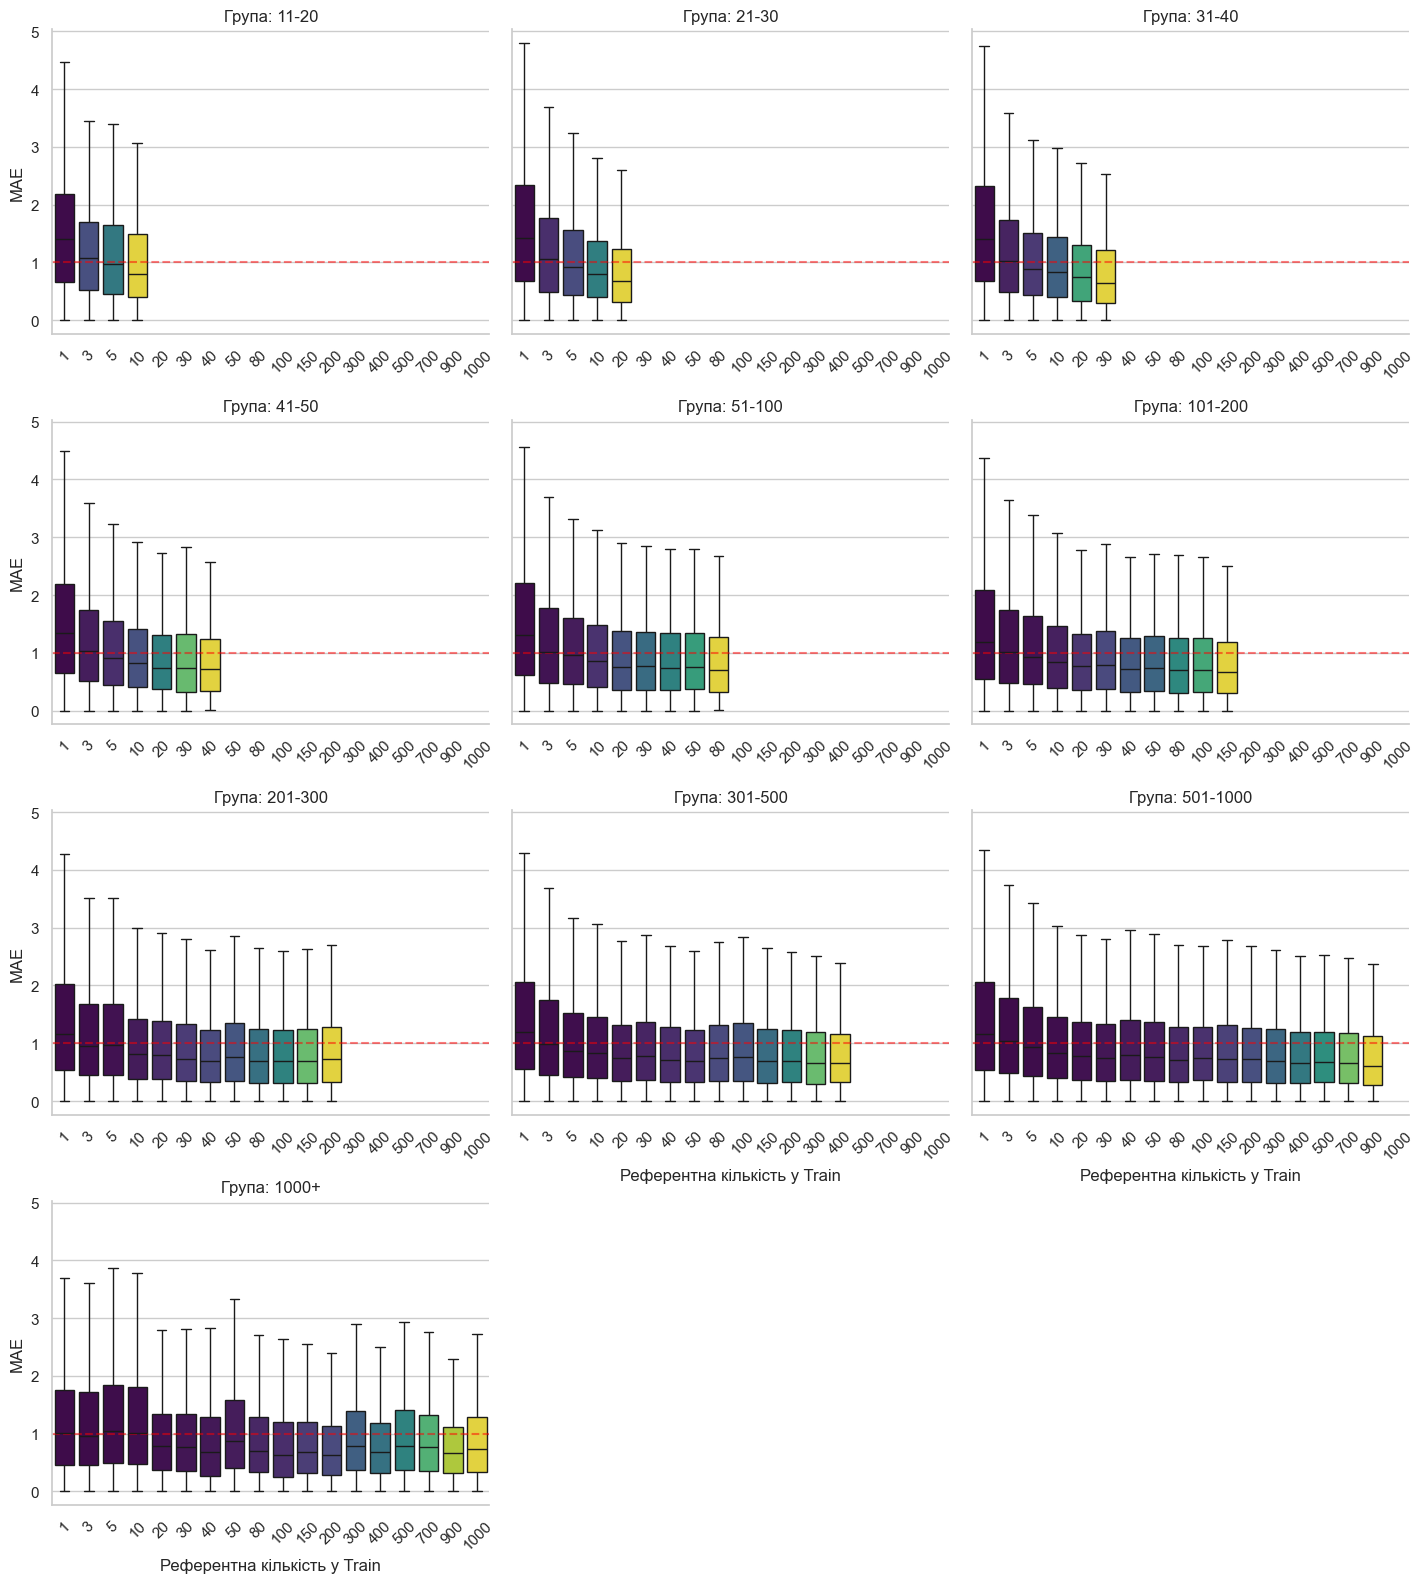

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Підготовка точок
ref_points = [1, 3, 5, 10, 20, 30, 40, 50, 80, 100, 150, 200, 300, 400, 500, 700, 900, 1000]

df_ref = df_main_test[df_main_test['train_count'].isin(ref_points)].copy()

# 2. Побудова через FacetGrid (це виправить UnboundLocalError)
# Створюємо сітку
g = sns.FacetGrid(
    df_ref, 
    col="activity_group", 
    col_wrap=3, 
    height=4, 
    aspect=1.2, 
    sharex=False # Важливо! У кожної групи своя шкала Train
)

# Малюємо боксплоти вручну на сітці
g.map_dataframe(
    sns.boxplot, 
    x="train_count", 
    y="abs_error", 
    order=ref_points, # Однаковий порядок для порівняння
    showfliers=False,
    palette="viridis",
    hue="train_count", # Додаємо hue для кольору, щоб уникнути помилок Seaborn
    legend=False
)

# Налаштування
for ax in g.axes.flat:
    ax.axhline(1.0, color='red', linestyle='--', alpha=0.5)
    # Залишаємо на осі X тільки ті точки, які існують для цієї групи
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

g.set_axis_labels("Референтна кількість у Train", "MAE")
g.set_titles("Група: {col_name}")
plt.tight_layout()
plt.show()

C:\Users\Anton\AppData\Local\Temp\ipykernel_21508\2451659948.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


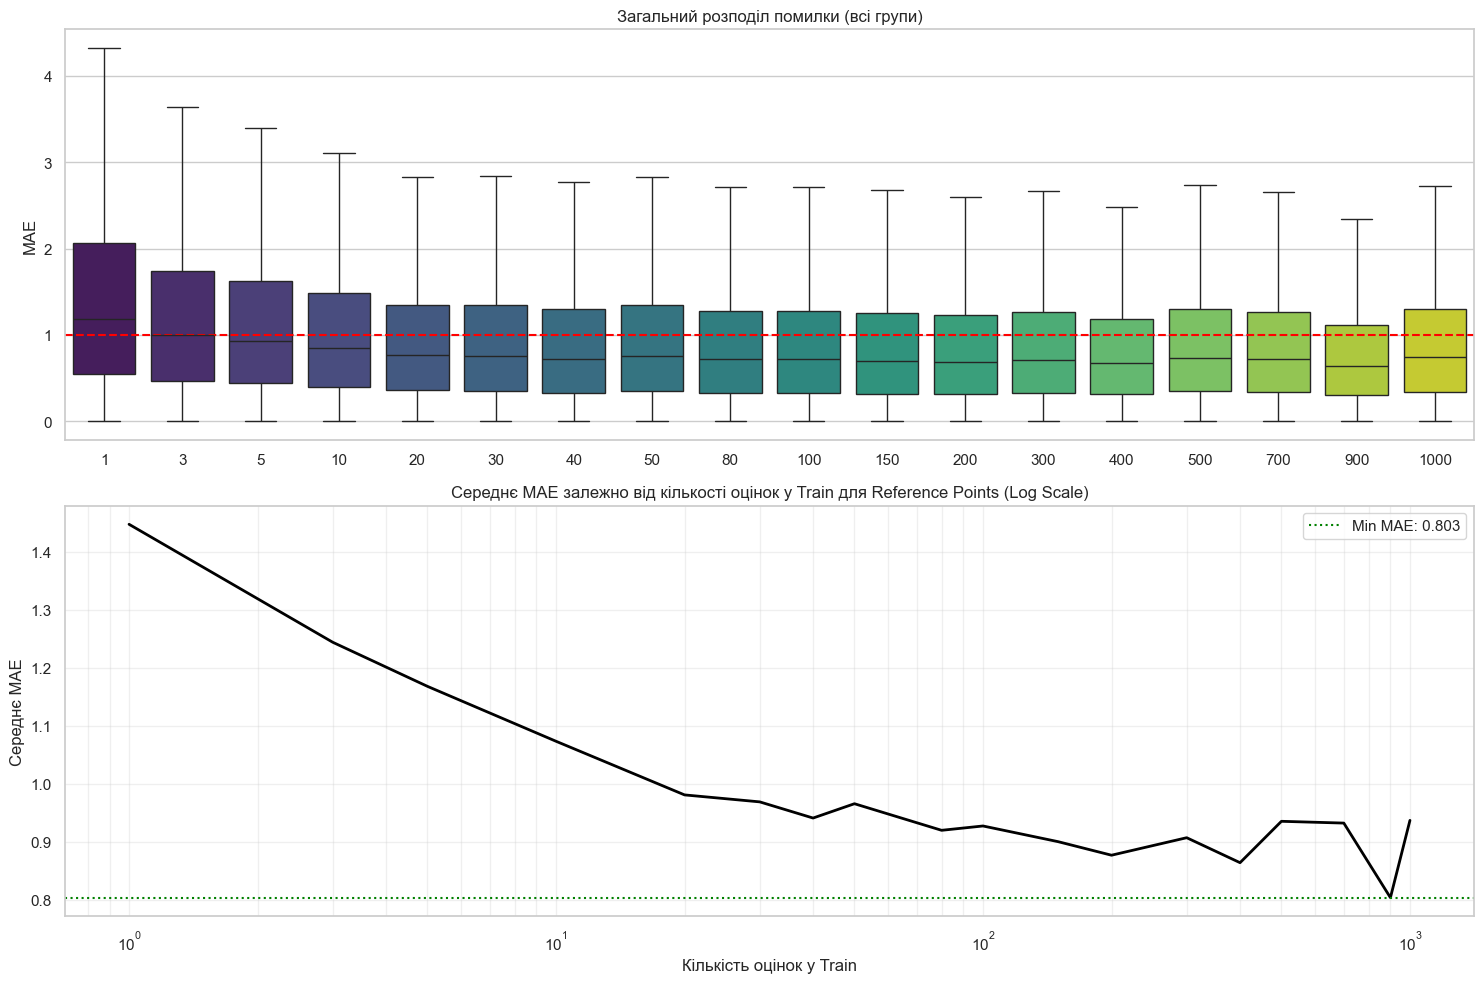

In [41]:

plt.figure(figsize=(15, 10))

# --- ГРАФІК 1: Загальний Boxplot для всіх ---
plt.subplot(2, 1, 1)
sns.boxplot(
    data=df_ref, 
    x='train_count', 
    y='abs_error', 
    showfliers=False, 
    palette='viridis'
)
plt.axhline(1.0, color='red', linestyle='--', label='Поріг 1.0')
plt.title('Загальний розподіл помилки (всі групи)')
plt.ylabel('MAE')
plt.xlabel('') # прибираємо, щоб не накладалося

# --- ГРАФІК 2: Лінійний тренд середнього MAE ---
plt.subplot(2, 1, 2)
# Розраховуємо середнє MAE для кожної кількості Train
mean_mae = df_ref.groupby('train_count')['abs_error'].mean().reset_index()

sns.lineplot(data=mean_mae, x='train_count', y='abs_error', color='black', linewidth=2)
plt.xscale('log') # Логарифмічна шкала для кращої візуалізації початку
plt.axhline(mean_mae['abs_error'].min(), color='green', linestyle=':', label=f'Min MAE: {mean_mae["abs_error"].min():.3f}')

plt.title('Середнє MAE залежно від кількості оцінок у Train для Reference Points (Log Scale)')
plt.xlabel('Кількість оцінок у Train')
plt.ylabel('Середнє MAE')
plt.legend()
plt.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

C:\Users\Anton\AppData\Local\Temp\ipykernel_21508\2252438662.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


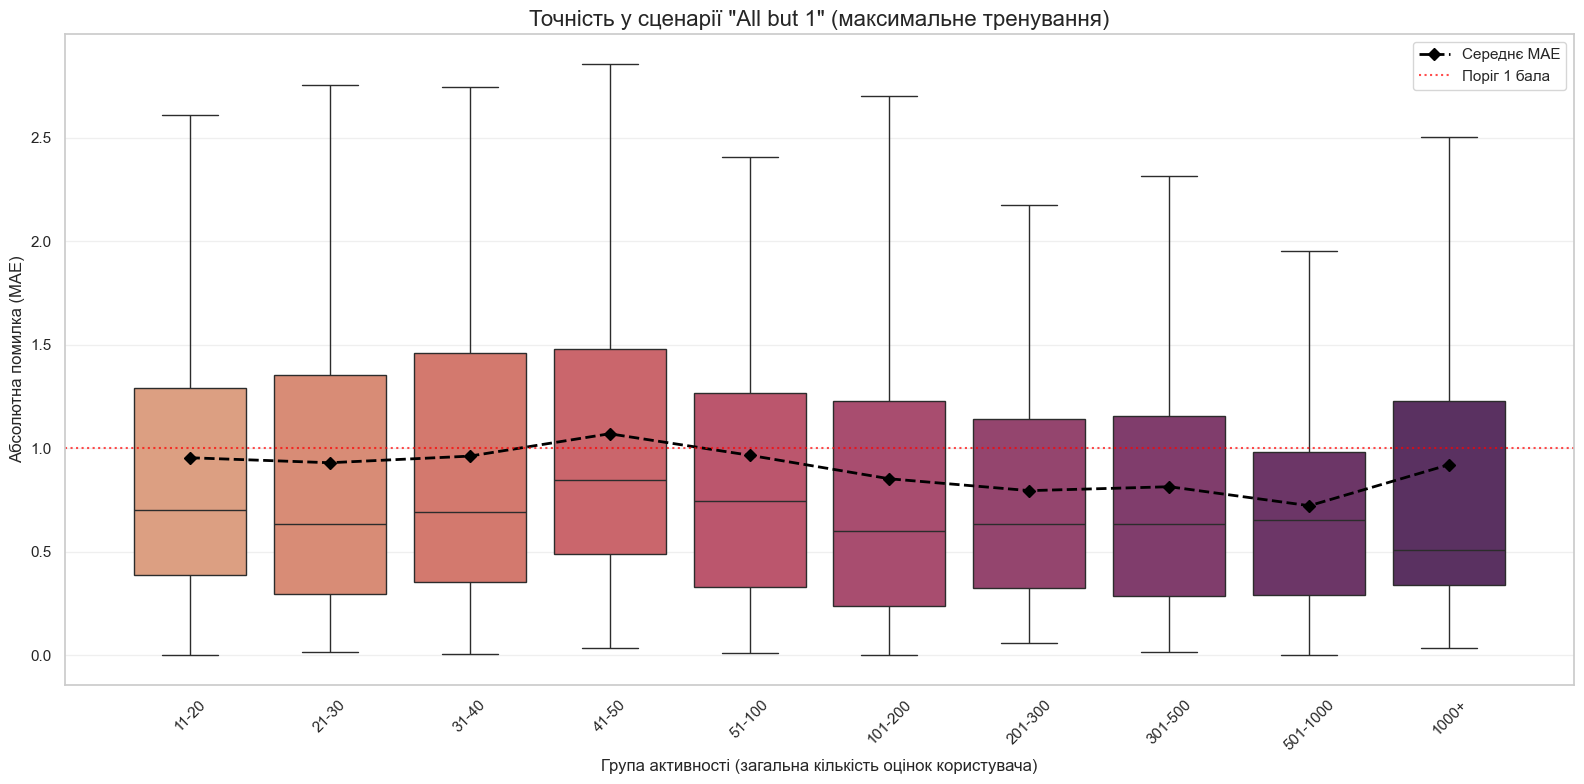

In [44]:
# 1. Готуємо дані (фільтруємо основний тест)
df_all_but_one = df_main_test[df_main_test['is_all_but_one'] == True].copy()

# Ми припускаємо, що в df_main_test для кожного користувача залишився 1 тестовий запис
plt.figure(figsize=(16, 8))

# 2. Будуємо Boxplot, де X - це групи активності
sns.boxplot(
    data=df_all_but_one, 
    x='activity_group', 
    y='abs_error', 
    palette='flare',
    showfliers=False # прибираємо викиди, щоб бачити основне "тіло" точності
)

# 3. Додаємо лінію середнього MAE для наочності тренду
mean_values = df_all_but_one.groupby('activity_group')['abs_error'].mean().values
plt.plot(range(len(mean_values)), mean_values, color='black', marker='D', linestyle='--', linewidth=2, label='Середнє MAE')

# Налаштування
plt.axhline(1.0, color='red', linestyle=':', alpha=0.7, label='Поріг 1 бала')
plt.title('Точність у сценарії "All but 1" (максимальне тренування)', fontsize=16)
plt.ylabel('Абсолютна помилка (MAE)', fontsize=12)
plt.xlabel('Група активності (загальна кількість оцінок користувача)', fontsize=12)
plt.xticks(rotation=45)
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [43]:
df_main_test

,user_id,anime_id,rating,activity_group,total_ratings,train_count,train_percent,is_all_but_one,series_id,x_pct,...,user_encoded,anime_encoded,target,predicted_rating,actual_rating,abs_error,sq_error,train_pct_bin,train_bin,ref_point
0,20,36754,8,51-100,79,29,36.71,False,NaN,NaN,...,17,12858,0.8,6.370934,8.0,1.629066,2.653854,30,21-50,20
1,20,16498,8,51-100,79,29,36.71,False,NaN,NaN,...,17,7362,0.8,9.104629,8.0,1.104629,1.220204,30,21-50,20
2,20,35507,7,51-100,79,29,36.71,False,NaN,NaN,...,17,12222,0.7,8.247402,7.0,1.247402,1.556012,30,21-50,20
3,20,36456,9,51-100,79,29,36.71,False,NaN,NaN,...,17,12681,0.9,8.678793,9.0,0.321207,0.103174,30,21-50,20
4,20,34134,7,51-100,79,29,36.71,False,NaN,NaN,...,17,11599,0.7,7.264456,7.0,0.264456,0.069937,30,21-50,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2413976,353395,3456,8,501-1000,738,500,67.75,False,NaN,NaN,...,280502,3038,0.8,8.524489,8.0,0.524489,0.275089,60,201-500,500
2413977,353395,25731,8,501-1000,738,500,67.75,False,NaN,NaN,...,280502,9138,0.8,7.269214,8.0,0.730786,0.534049,60,201-500,500
2413978,353395,2905,7,501-1000,738,500,67.75,False,NaN,NaN,...,280502,2650,0.7,6.985555,7.0,0.014445,0.000209,60,201-500,500
2413979,353395,2926,8,501-1000,738,500,67.75,False,NaN,NaN,...,280502,2665,0.8,8.473203,8.0,0.473203,0.223921,60,201-500,500


C:\Users\Anton\AppData\Local\Temp\ipykernel_21508\3721443623.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


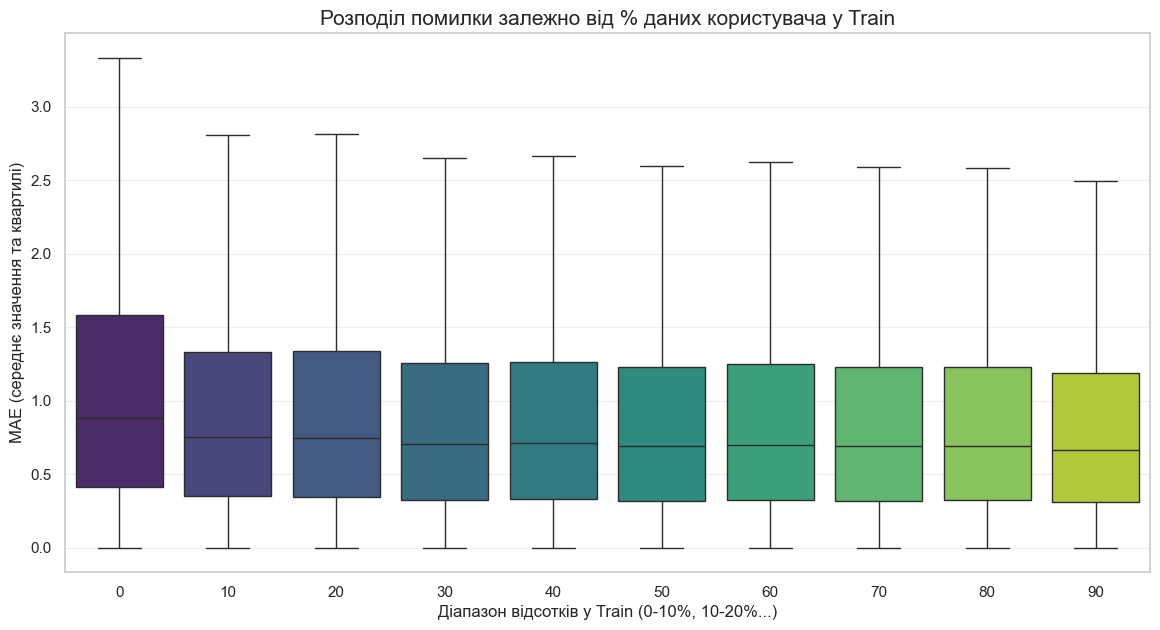

In [18]:
# Округлимо відсотки до 10%, щоб графік був читабельним (бінування)
df_main_test['train_pct_bin'] = (df_main_test['train_percent'] // 10 * 10).astype(int)

plt.figure(figsize=(14, 7))

sns.boxplot(
    data=df_main_test, 
    x='train_pct_bin', 
    y='abs_error', 
    showfliers=False, # Прибираємо викиди для чистоти візуалізації
    palette='viridis'
)

plt.title('Розподіл помилки залежно від % даних користувача у Train', fontsize=15)
plt.xlabel('Діапазон відсотків у Train (0-10%, 10-20%...)', fontsize=12)
plt.ylabel('MAE (середнє значення та квартилі)', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

C:\Users\Anton\AppData\Local\Temp\ipykernel_21508\4210044503.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(
C:\Users\Anton\AppData\Local\Temp\ipykernel_21508\4210044503.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
C:\Users\Anton\AppData\Local\Temp\ipykernel_21508\4210044503.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
C:\Users\Anton\AppData\Local\Temp\ipykernel_21508\4210044503.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xtick

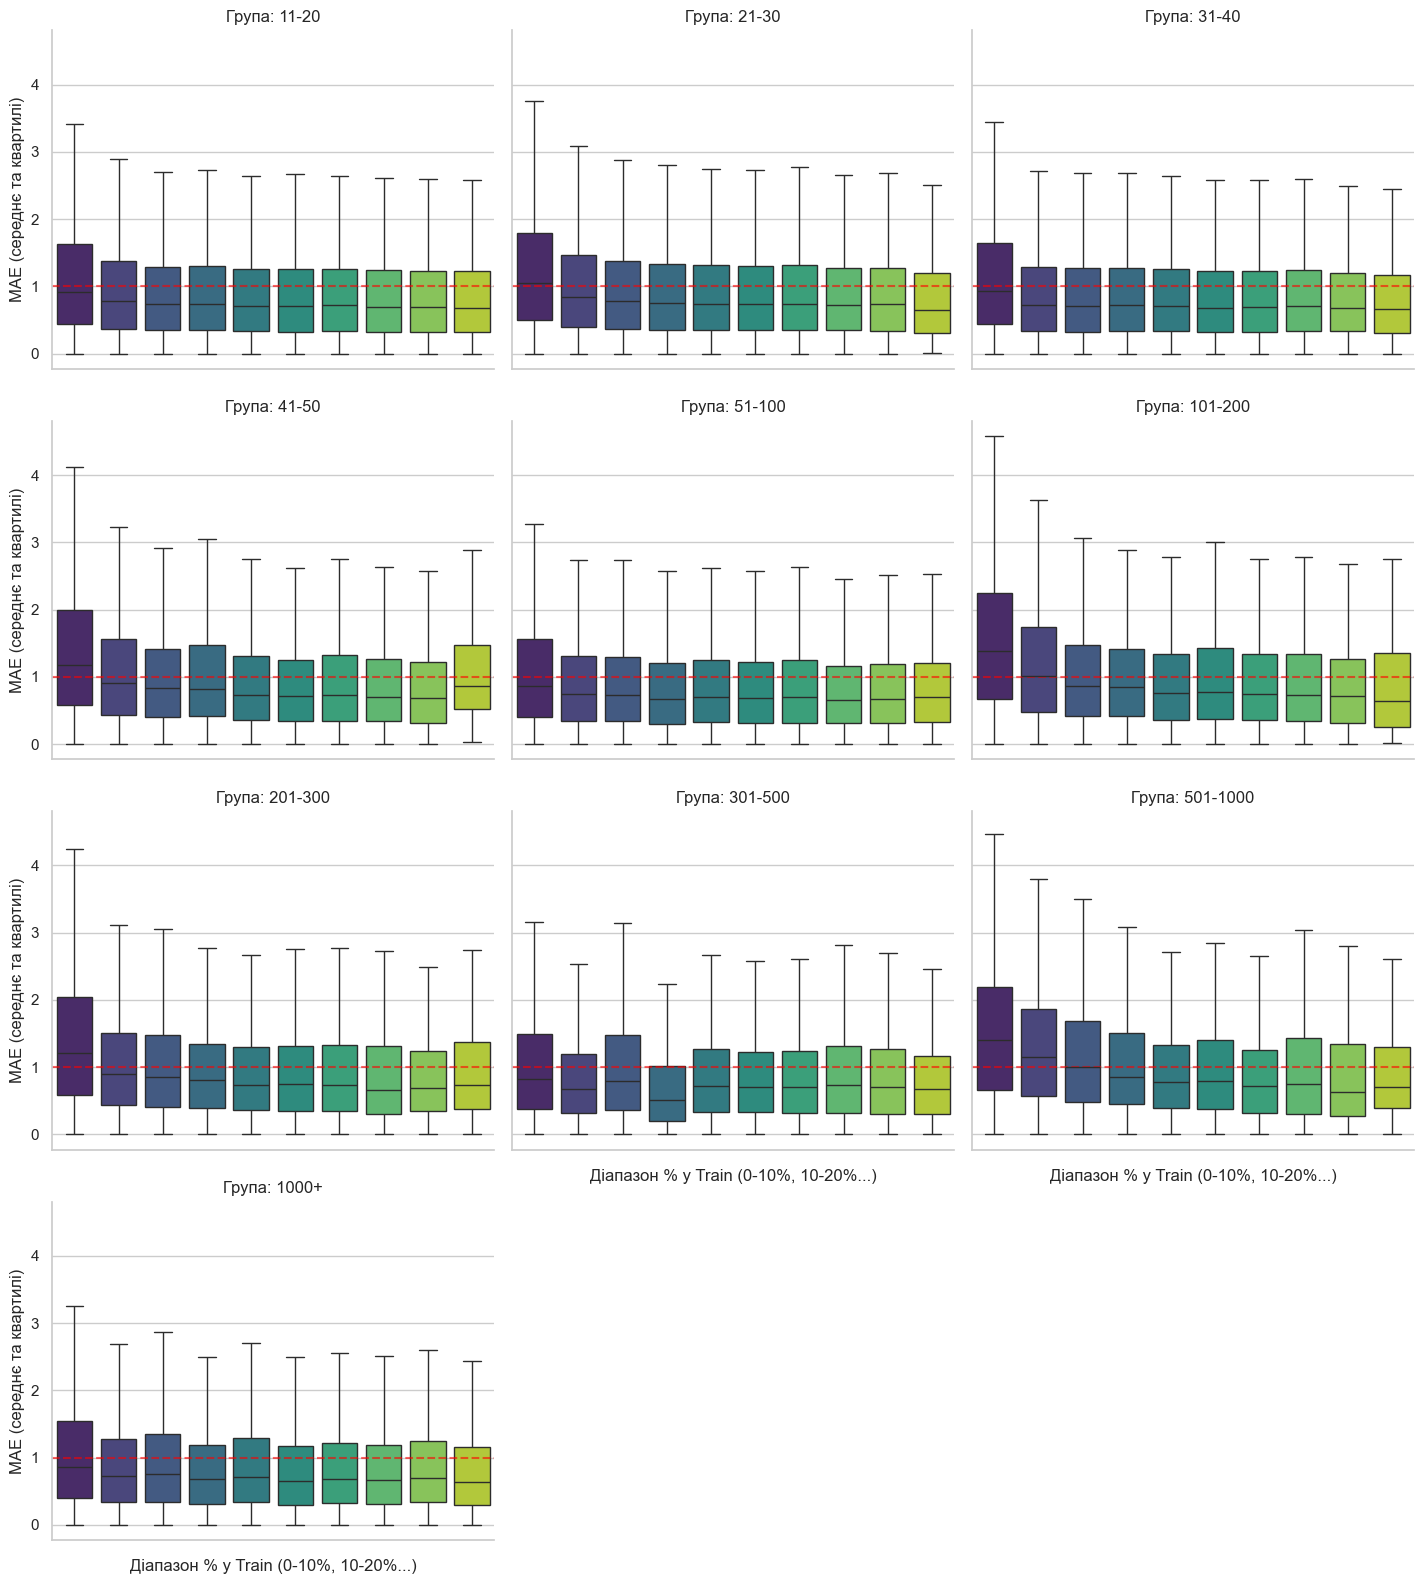

In [46]:
# 1. Побудова фасетних боксплотів
g = sns.catplot(
    data=df_main_test,
    x='train_pct_bin',
    y='abs_error',
    col='activity_group',
    col_wrap=3,           # Кількість графіків у рядку
    kind='box',
    showfliers=False,     # Прибираємо викиди для кращої візуалізації "тіла" помилки
    height=4,
    aspect=1.2,
    palette='viridis'
)

# 3. Налаштування осей та додавання референтної лінії
for ax in g.axes.flat:
    ax.axhline(1.0, color='red', linestyle='--', alpha=0.6)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

g.set_axis_labels("Діапазон % у Train (0-10%, 10-20%...)", "MAE (середнє та квартилі)")
g.set_titles("Група: {col_name}")

plt.tight_layout()
plt.show()

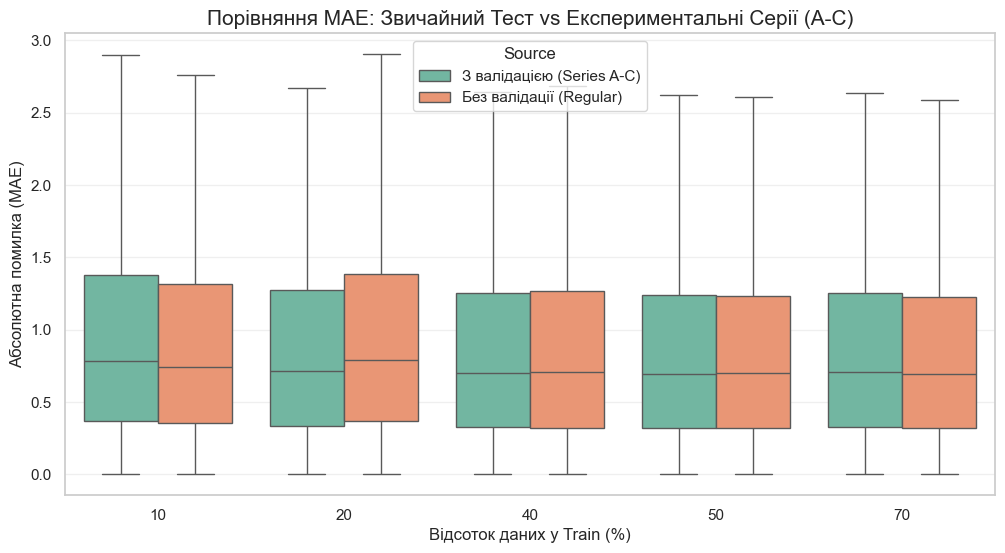

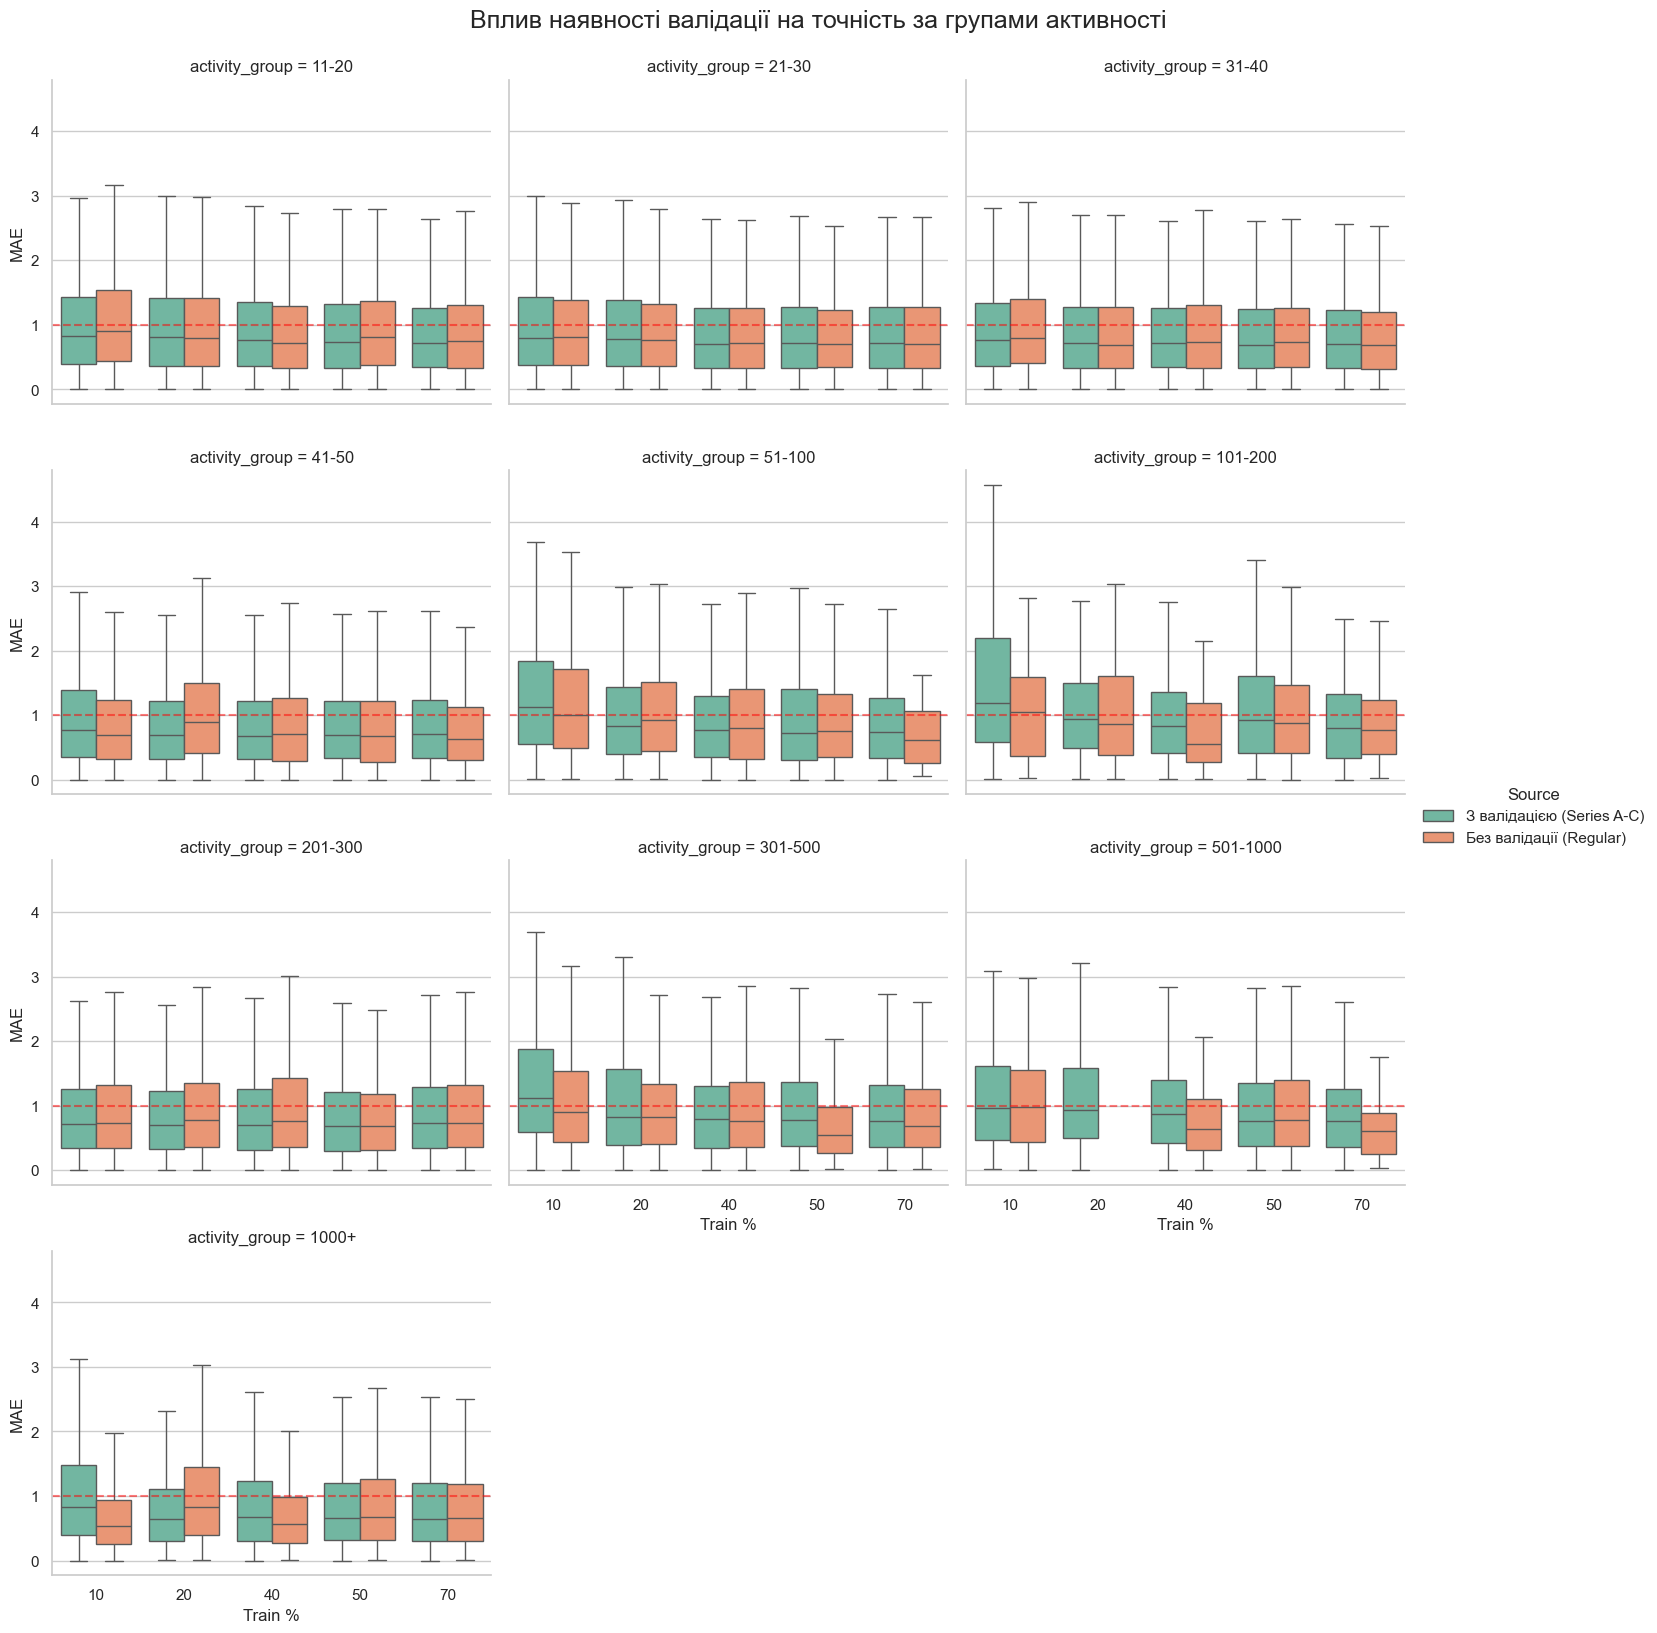

In [48]:
# 1. Визначаємо референтні відсотки Train, які були в серіях
target_pcts = [10, 20, 40, 50, 70]

# 2. Розділяємо дані на "Серійні" та "Звичайні"
# Серійні - ті, що мають ідентифікатор A, B або C
df_serial = test[test['series_id'].isin(['A_FixedTest', 'B_FixedTrain', 'C_FixedVal'])].copy()
df_serial['Source'] = 'З валідацією (Series A-C)'

# Звичайні - ті, що не мають серійного ID (основний пул)
df_regular = test[test['series_id'].isna()].copy()
df_regular['Source'] = 'Без валідації (Regular)'

# 3. Об'єднуємо та фільтруємо лише потрібні відсотки
compare_df = pd.concat([df_serial, df_regular])

# Округляємо x_pct (або train_percent), щоб знайти точні співпадіння
compare_df['train_pct_int'] = compare_df['x_pct'].fillna(compare_df['train_percent']).round().astype(int)
compare_df = compare_df[compare_df['train_pct_int'].isin(target_pcts)]

# --- ГРАФІК 1: Загальне порівняння ---
plt.figure(figsize=(12, 6))
sns.boxplot(data=compare_df, x='train_pct_int', y='abs_error', hue='Source', showfliers=False, palette='Set2')
plt.title('Порівняння MAE: Звичайний Тест vs Експериментальні Серії (A-C)', fontsize=15)
plt.xlabel('Відсоток даних у Train (%)', fontsize=12)
plt.ylabel('Абсолютна помилка (MAE)', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

# --- ГРАФІК 2: Порівняння за групами активності ---
g = sns.catplot(
    data=compare_df,
    x='train_pct_int',
    y='abs_error',
    hue='Source',
    col='activity_group',
    col_wrap=3,
    kind='box',
    showfliers=False,
    height=4,
    aspect=1.2,
    palette='Set2'
)

for ax in g.axes.flat:
    ax.axhline(1.0, color='red', linestyle='--', alpha=0.5)

g.fig.suptitle('Вплив наявності валідації на точність за групами активності', fontsize=18, y=1.02)
g.set_axis_labels("Train %", "MAE")
plt.show()

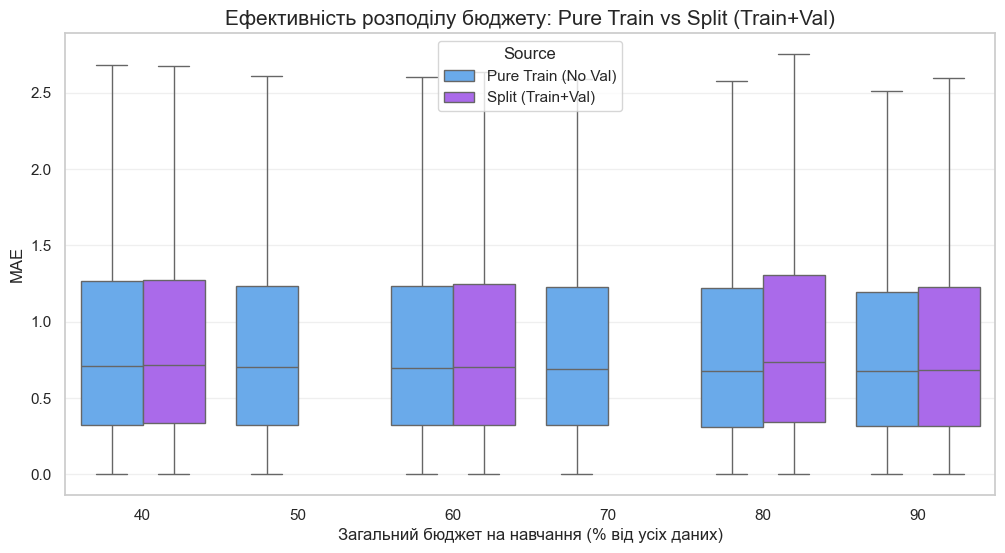

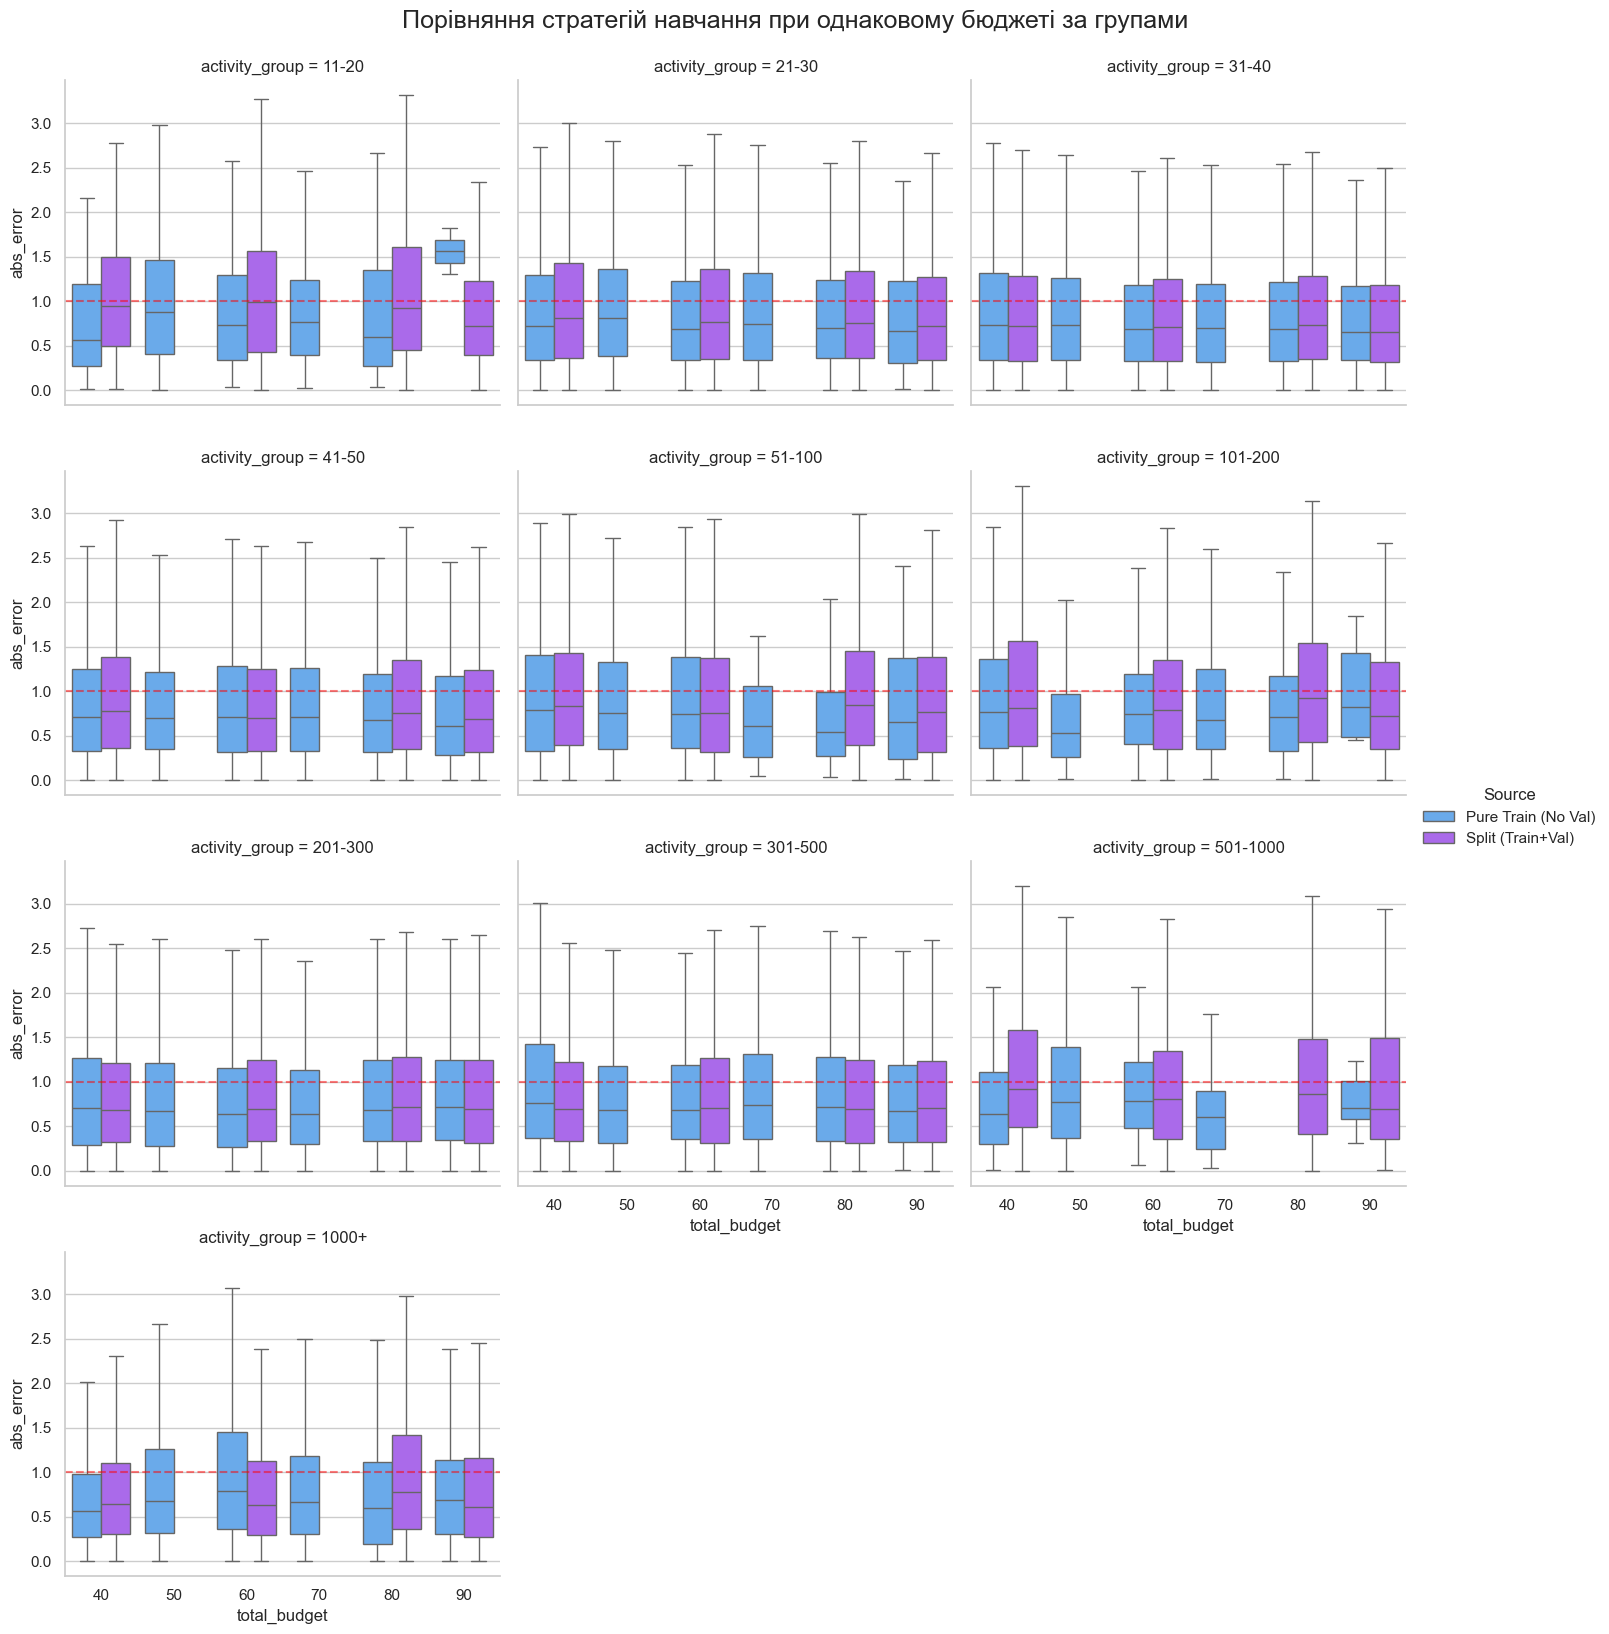

In [50]:
# 1. Розраховуємо "Навчальний бюджет" (Total Training Budget)
# Для серійних даних це x_pct + y_pct
# Для звичайних даних це просто train_percent (оскільки val_percent там 0)

test['total_budget'] = 0

# Обробка серійних даних (A, B, C)
serial_mask = test['series_id'].isin(['A_FixedTest', 'B_FixedTrain', 'C_FixedVal'])
test.loc[serial_mask, 'total_budget'] = (test['x_pct'] + test['y_pct']).round()

# Обробка звичайних даних
regular_mask = test['series_id'].isna()
test.loc[regular_mask, 'total_budget'] = test['train_percent'].round()

# 2. Визначаємо спільні бюджети для порівняння
# В Серії А бюджет завжди 80% (x+y, бо z=20). В інших серіях він варіюється.
# Візьмемо найбільш часті значення бюджетів, наприклад: 40, 50, 60, 70, 80, 90
common_budgets = [40, 50, 60, 70, 80, 90]

# 3. Підготовка даних для порівняння
compare_df = test[test['total_budget'].isin(common_budgets)].copy()
compare_df['Source'] = compare_df['series_id'].apply(lambda x: 'Split (Train+Val)' if pd.notna(x) else 'Pure Train (No Val)')

# --- ГРАФІК 1: Загальне порівняння бюджетів ---
plt.figure(figsize=(12, 6))
sns.boxplot(data=compare_df, x='total_budget', y='abs_error', hue='Source', showfliers=False, palette='cool')
plt.title('Ефективність розподілу бюджету: Pure Train vs Split (Train+Val)', fontsize=15)
plt.xlabel('Загальний бюджет на навчання (% від усіх даних)', fontsize=12)
plt.ylabel('MAE')
plt.grid(axis='y', alpha=0.3)
plt.show()

# --- ГРАФІК 2: Порівняння за групами активності ---
g = sns.catplot(
    data=compare_df,
    x='total_budget',
    y='abs_error',
    hue='Source',
    col='activity_group',
    col_wrap=3,
    kind='box',
    showfliers=False,
    height=4,
    aspect=1.2,
    palette='cool'
)

for ax in g.axes.flat:
    ax.axhline(1.0, color='red', linestyle='--', alpha=0.5)

g.fig.suptitle('Порівняння стратегій навчання при однаковому бюджеті за групами', fontsize=18, y=1.02)
plt.show()

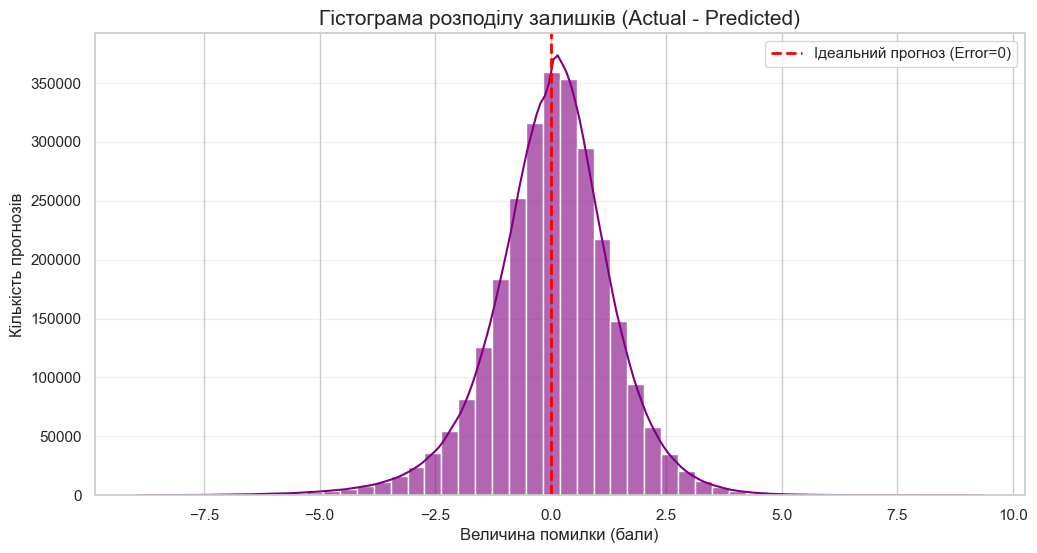

Середня помилка (Mean Error): 0.0165
Медіанна помилка (Median Error): 0.0783


In [52]:
# 1. Розраховуємо залишки (помилки)
# Actual - Predicted
test['error'] = test['actual_rating'] - test['predicted_rating']

# 2. Побудова графіка
plt.figure(figsize=(12, 6))
sns.histplot(test['error'], bins=50, kde=True, color='purple', alpha=0.6)

# Додаємо вертикальну лінію на рівні 0 (ідеальний прогноз)
plt.axvline(0, color='red', linestyle='--', linewidth=2, label='Ідеальний прогноз (Error=0)')

plt.title('Гістограма розподілу залишків (Actual - Predicted)', fontsize=15)
plt.xlabel('Величина помилки (бали)', fontsize=12)
plt.ylabel('Кількість прогнозів', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()

# Додаткова статистика
print(f"Середня помилка (Mean Error): {test['error'].mean():.4f}")
print(f"Медіанна помилка (Median Error): {test['error'].median():.4f}")